# Commodity-Trend Model vs. 60/40

Presentation notebook for the completed analysis. This notebook loads prepared outputs and delegates plotting, table formatting, and lightweight display analytics to `trend_analysis` modules.

In [1]:
from pathlib import Path
import sys

from IPython.display import Markdown, display

NOTEBOOK_DIR = Path.cwd() if (Path.cwd() / "trend_analysis").exists() else Path.cwd() / "Notebooks"
sys.path.insert(0, str(NOTEBOOK_DIR))

from trend_analysis.config import BENCHMARK_6040, BONDS, COMMODITY_TREND, DYNAMIC_MV, EQUITY, SLEEVE_9010, STATIC_MV
from trend_analysis.data import (
    expected_output_files,
    load_core_summary,
    load_drawdown_buckets,
    load_drawdown_episodes,
    load_dynamic_weights,
    load_five_strategy_summary,
    load_merged_daily,
    load_part5_calendar,
    load_part5_conditional,
    load_part6_conditional,
    load_part6_counts,
    load_part6_stress,
    load_quantile_windows,
    load_sleeve_summary,
    load_static_mv_weights,
    prepare_core_and_strategy_returns,
)
from trend_analysis.original_style import (
    display_evaluation_block,
    display_metric_table,
    dual_beta_regression_table,
    format_metric_table,
    monthly_return_heatmap_original,
    plot_annual_return_bars,
    plot_benchmark_drawdown,
    plot_core_daily_returns,
    plot_core_nav,
    plot_correlation_combo_original,
    plot_drawdown_buckets_original,
    plot_drawdown_episode_bars_original,
    plot_drawdown_episode_timeline_original,
    plot_drawdown_original,
    plot_dynamic_weight_step,
    plot_mean_variance_frontier_original,
    plot_nav_original,
    plot_part5_active_return_boxplots_original,
    plot_part6_active_return_boxplots_original,
    plot_part6_metric_panel_original,
    plot_quintile_matched_bars_original,
    plot_relative_wealth_original,
    plot_return_scatter_original,
    plot_stacked_annual_returns_original,
    plot_stacked_drawdowns_original,
    plot_stock_bond_corr_original,
    plot_stress_matched_panels_original,
    style_regression_table,
)
from trend_analysis.plots import apply_theme
from trend_analysis.tables import presentation_table, style_summary_table

apply_theme()

## Data Inputs

Expects the analysis CSVs in `Notebooks/output/` to already exist.

In [2]:
missing = [path.name for path in expected_output_files() if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing presentation inputs: {missing}")

merged = load_merged_daily()
returns, core_returns, strategy_returns = prepare_core_and_strategy_returns()
core_summary = load_core_summary()
sleeve_summary = load_sleeve_summary()
five_strategy_summary = load_five_strategy_summary()
static_mv_weights = load_static_mv_weights()
dynamic_weights = load_dynamic_weights()
episodes = load_drawdown_episodes()
quantile_windows = load_quantile_windows()
drawdown_buckets = load_drawdown_buckets()
part5_calendar = load_part5_calendar()
part5_conditional = load_part5_conditional()
part6_counts = load_part6_counts()
part6_conditional = load_part6_conditional()
part6_stress = load_part6_stress()

## Part 1 — Core Performance

The Commodity-Trend Model and the 60/40 benchmark are shown on the same daily calendar using growth of $1, daily returns, drawdowns, and benchmark-only calendar context.

In [3]:
display_metric_table(core_summary)

,Metric,Commodity-Trend Model,60/40
0,Start date,2002-01-01,2002-01-01
1,End date,2026-04-20,2026-04-20
2,Initial AUM,100000000,100000000
3,Ending NAV,283449790.2192844,602519538.4009718
4,Total return,1.8344979021928443,5.025195384009717
5,Annual rate of return,0.04381040971314376,0.07671225737098064
6,Annualized volatility,0.07083689994005843,0.10868137947714859
7,"Sharpe ratio, rf=0",0.6184687606348633,0.7058454515394719
8,Maximum drawdown,-0.15933386037892394,-0.3268328292060485
9,Maximum drawdown start,2008-07-14,2007-10-09


Commodity-Trend earned 4.38% annualized vs 7.67% for 60/40 from 2002 to 2026, ending at $283.4M vs $602.5M on a $100M start. Risk was lower across the board: 7.08% vol vs 10.87%, and a -15.93% max drawdown vs -32.68%.

<Axes: title={'center': 'Daily Returns'}, ylabel='Return'>

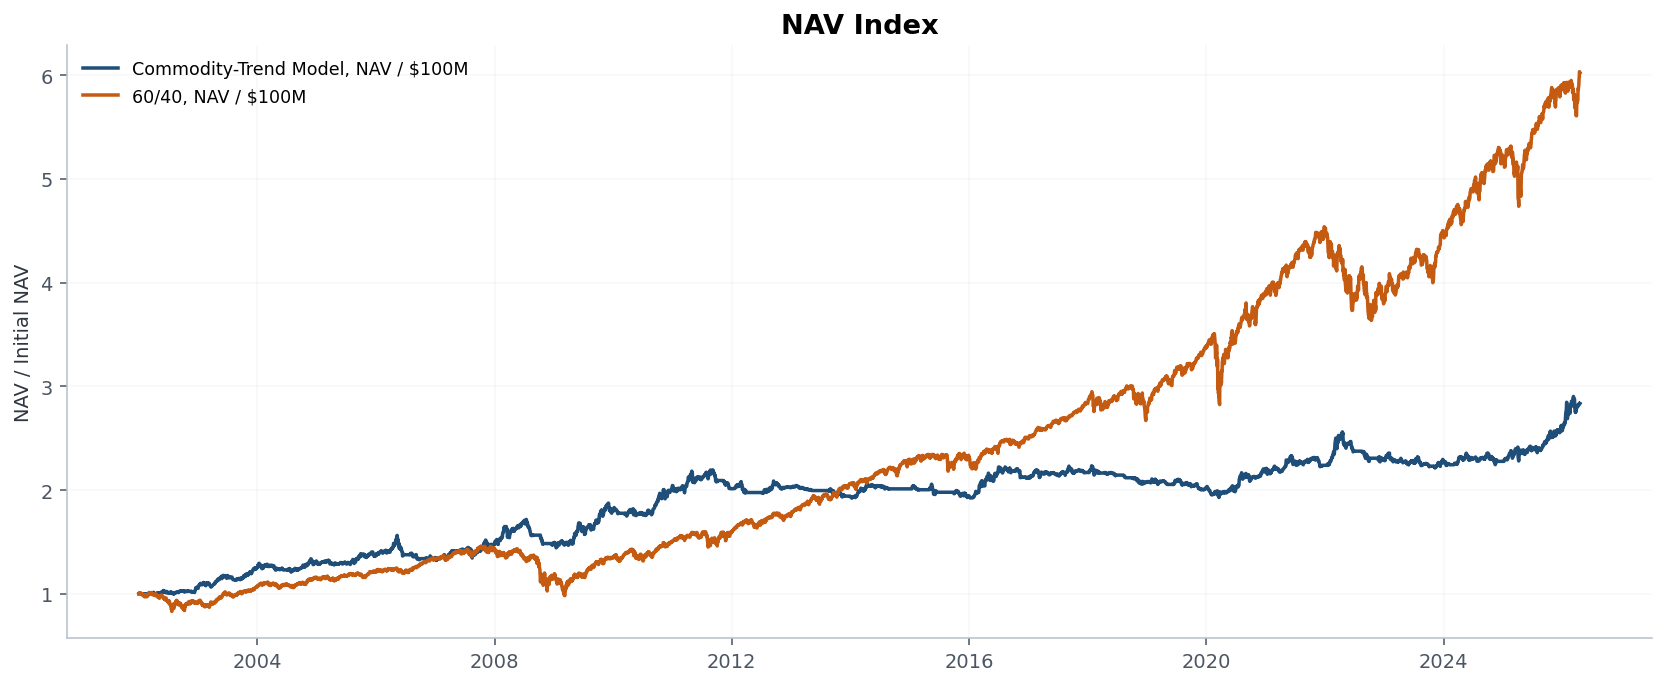

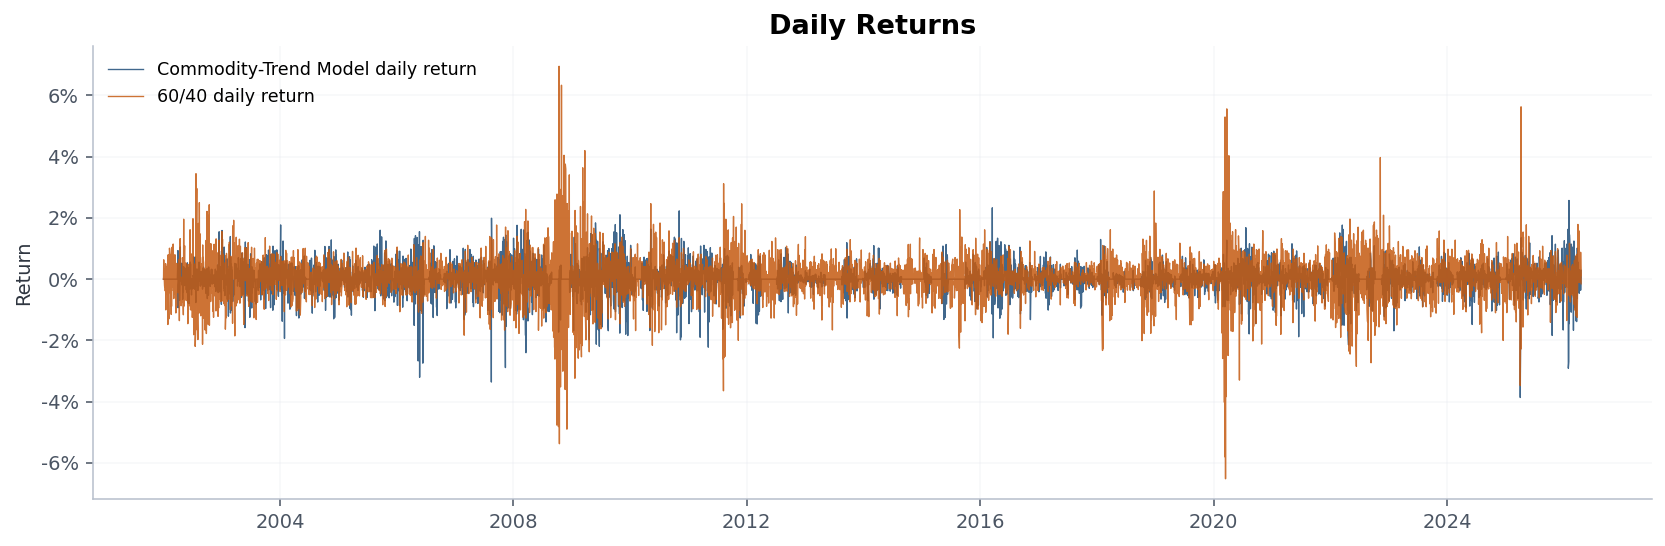

In [4]:
plot_core_nav(merged)
plot_core_daily_returns(core_returns)

60/40 compounded more wealth ($602.5M vs $283.4M ending NAV on a $100M start), but Commodity-Trend's path was smoother. Worst daily loss was -3.86% vs -6.52% for 60/40.

Month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
Year,,,,,,,,,,,,,
2002,-0.6%,-0.8%,1.3%,-2.7%,-0.2%,-3.7%,-3.6%,1.4%,-5.6%,4.9%,3.2%,-2.5%,-9.1%
2003,-1.6%,-0.2%,0.5%,5.1%,4.3%,0.5%,-0.7%,1.4%,0.6%,2.7%,0.6%,3.5%,17.9%
2004,1.5%,1.3%,-0.5%,-2.2%,0.7%,1.3%,-1.6%,1.1%,0.8%,1.3%,1.9%,2.4%,8.1%
2005,-1.2%,0.9%,-1.2%,-0.4%,2.4%,0.3%,1.7%,0.1%,-0.0%,-1.3%,2.5%,0.4%,4.2%
2006,1.5%,0.2%,0.3%,0.6%,-1.7%,0.2%,0.9%,2.0%,1.9%,2.2%,1.6%,0.5%,10.7%
2007,0.8%,-0.5%,0.7%,2.9%,1.7%,-1.0%,-1.2%,1.6%,2.5%,1.3%,-1.3%,-0.3%,7.3%
2008,-2.6%,-1.5%,0.1%,2.2%,0.3%,-4.8%,-0.3%,1.4%,-4.8%,-9.9%,-1.9%,2.3%,-18.3%
2009,-6.1%,-6.6%,6.4%,5.0%,3.0%,0.1%,4.7%,2.6%,2.6%,-1.1%,4.2%,0.1%,14.7%
2010,-1.5%,2.0%,3.2%,1.4%,-4.1%,-2.4%,4.5%,-1.9%,5.3%,2.2%,-0.2%,3.2%,11.9%


<Axes: title={'center': '60/40 Annual Returns'}, ylabel='Return'>

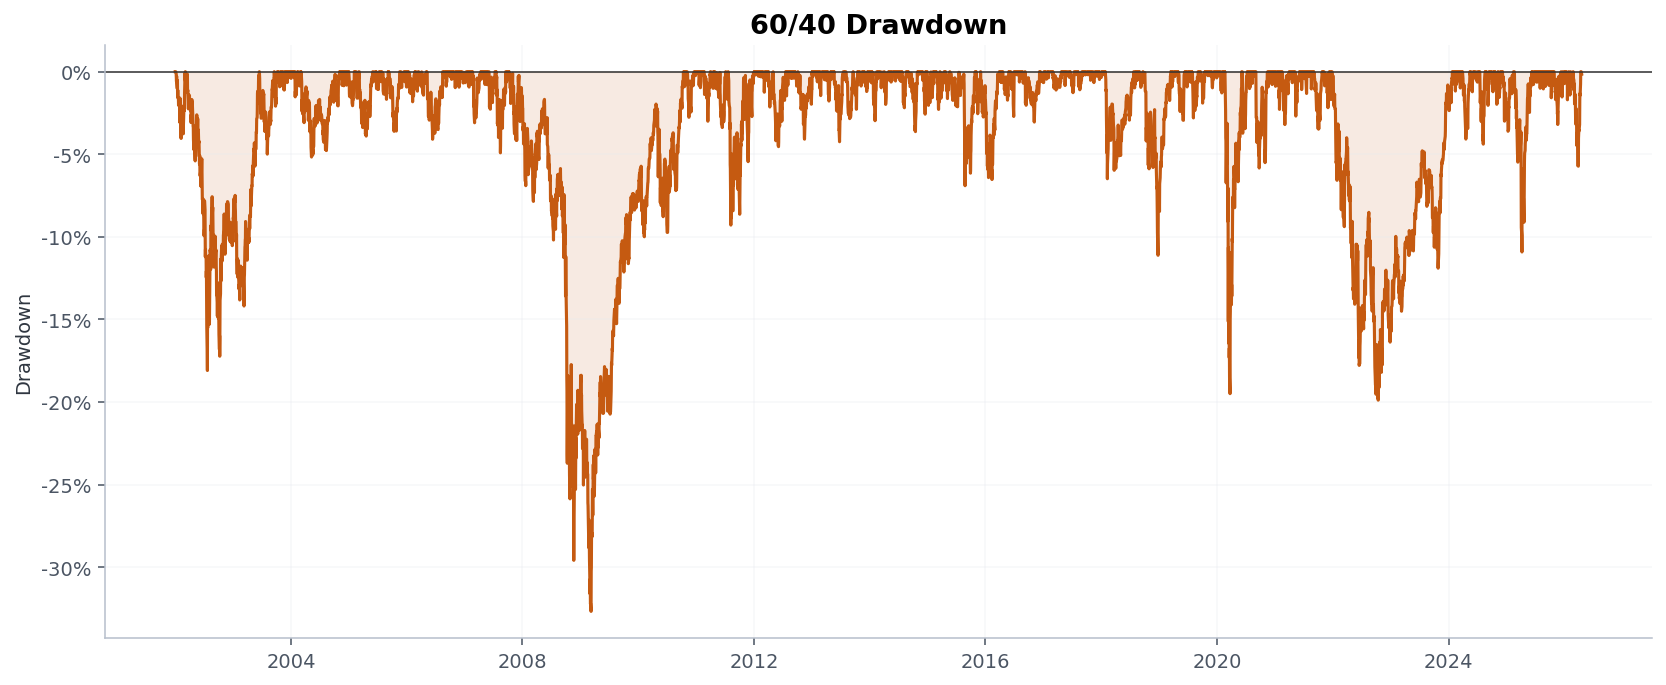

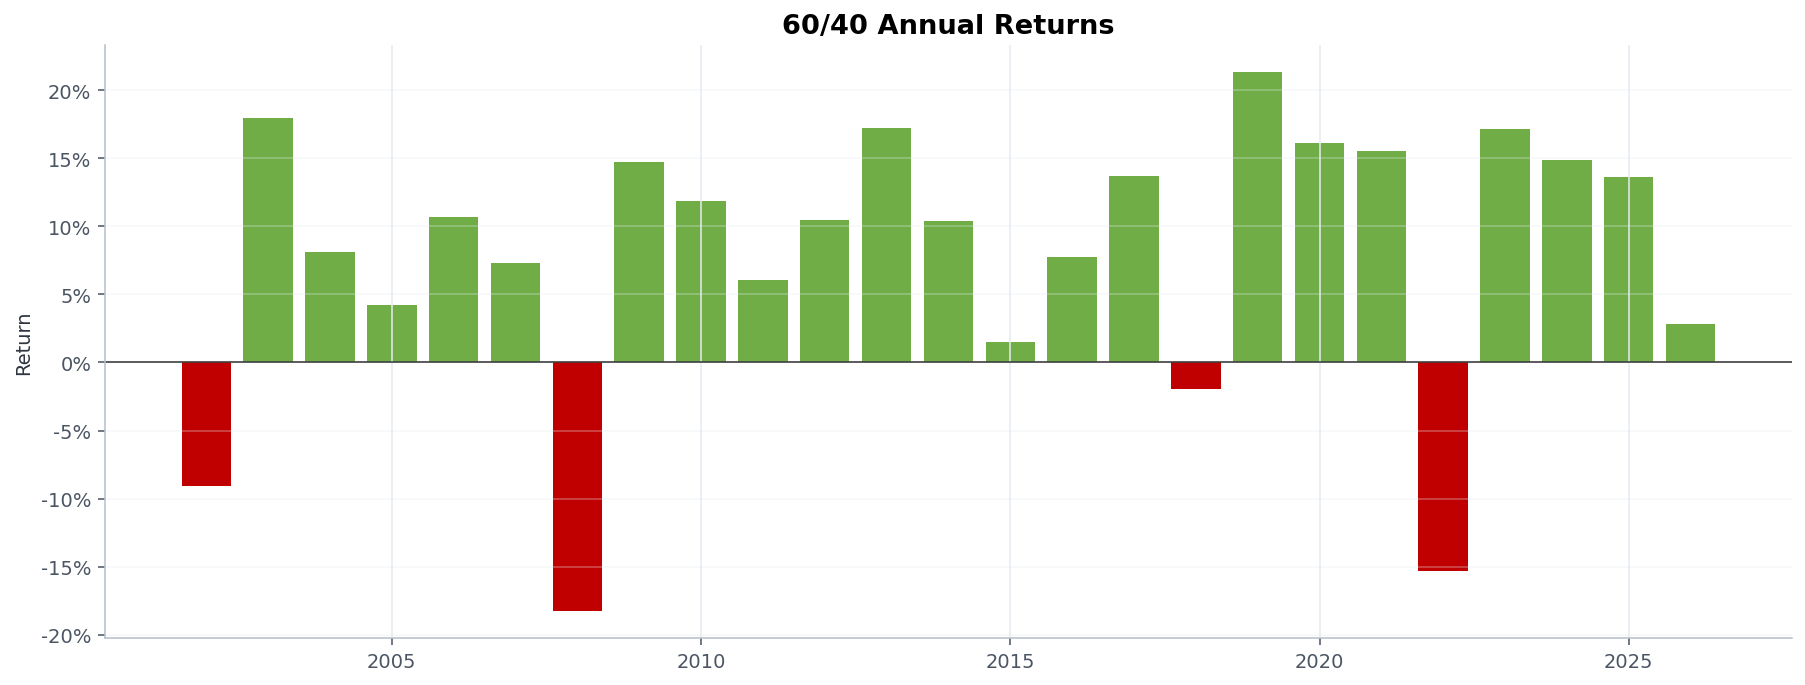

In [5]:
display(monthly_return_heatmap_original(core_returns[BENCHMARK_6040]))
plot_benchmark_drawdown(core_returns)
plot_annual_return_bars(core_returns[BENCHMARK_6040], "60/40 Annual Returns")

60/40's worst calendar years were 2008 (-18.3%) and 2022 (-15.3%). The worst single months were October 2008 (-9.9%), September 2022 (-6.9%), and February 2009 (-6.6%).

## Part 2 — Correlation

The relationship between the Commodity-Trend Model and 60/40 is summarized with daily-return scatter, rolling correlation, and calendar-year correlation.

/Users/jimmyzheng0516/Desktop/Project Labs/LTCM_sp_2026/Notebooks/trend_analysis/original_style.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


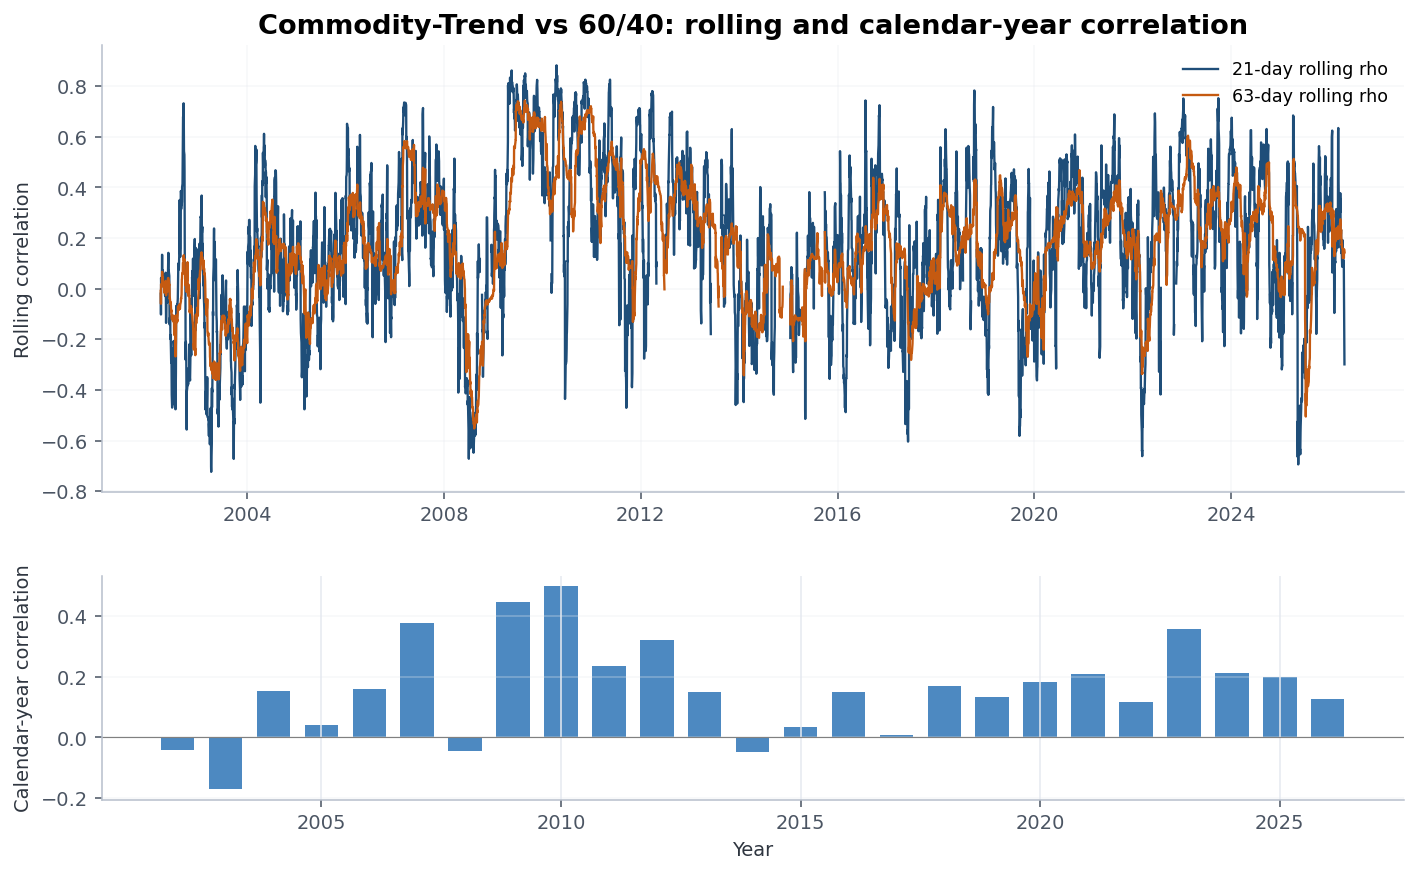

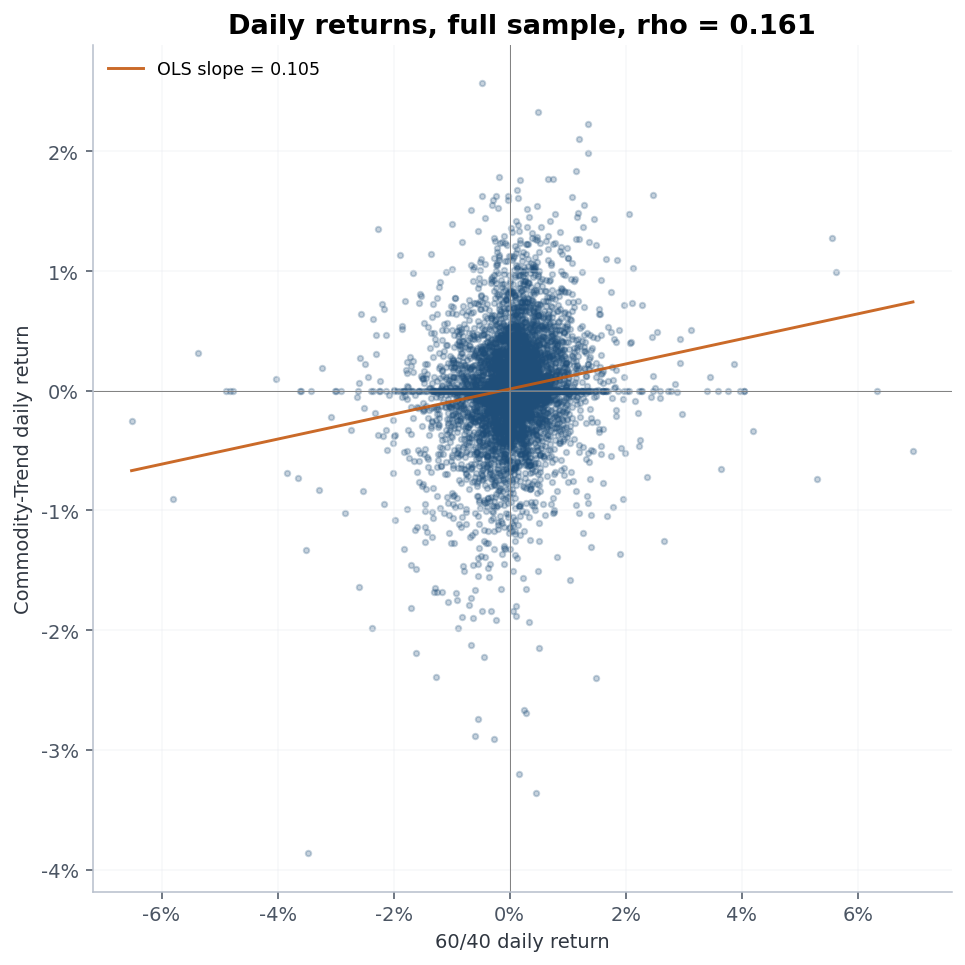

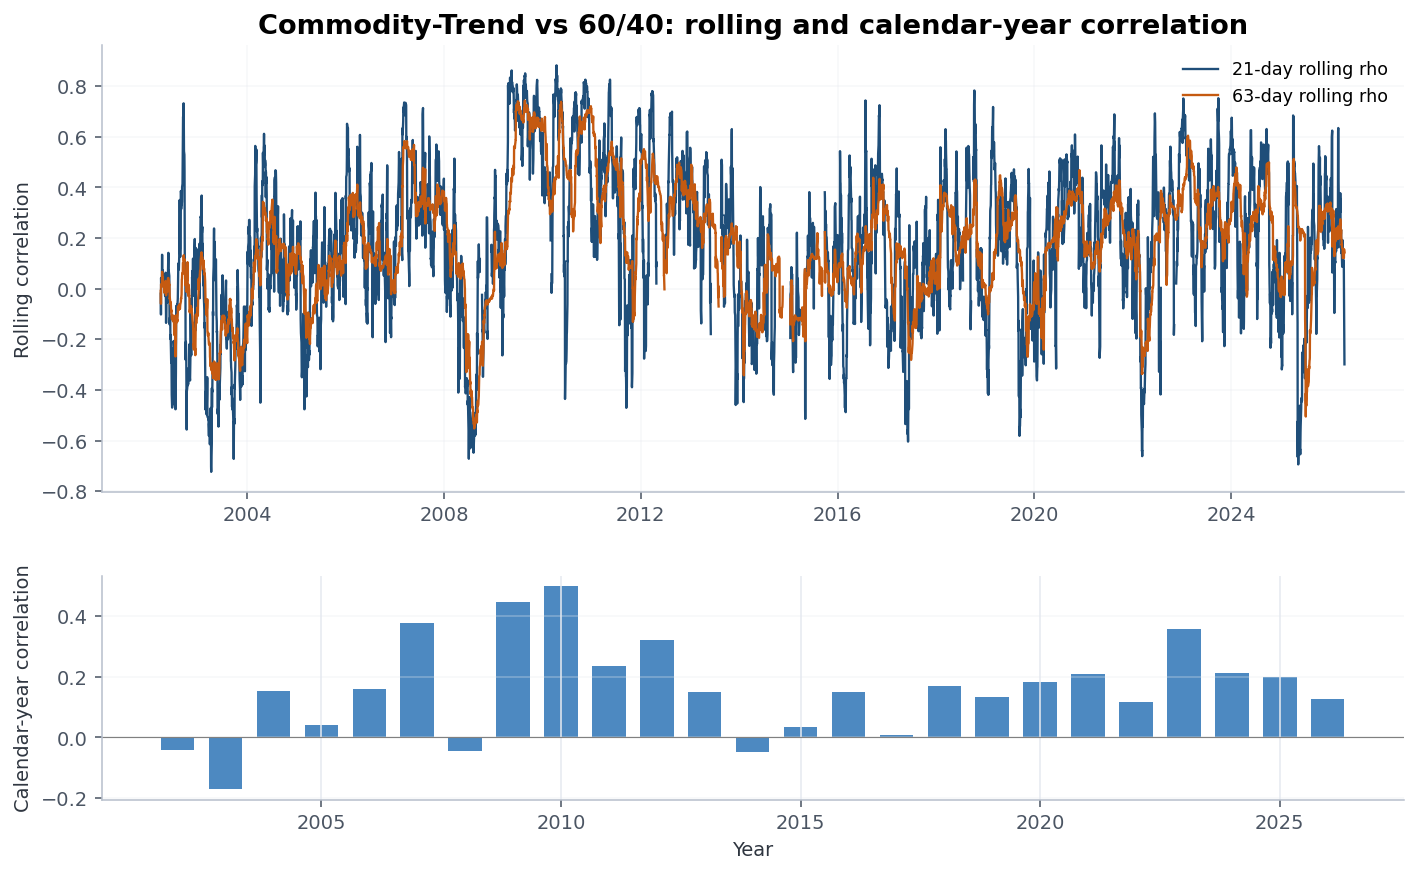

In [6]:
plot_return_scatter_original(core_returns)
plot_correlation_combo_original(core_returns)

Full-sample daily correlation with 60/40 is 0.16. The 252-day rolling correlation ranged from -0.21 to 0.64, and calendar-year correlation went negative in several years (2003: -0.17, 2008: -0.04), so the diversification benefit is real but regime-dependent.

## Part 3 — Diversification

The portfolio exhibits compare standalone 60/40, standalone Commodity-Trend exposure, a 90/10 blend, and long-only mean-variance allocations.

,Metric,60/40,90/10 Blend,Commodity-Trend Model
0,Start date,2002-01-02,2002-01-02,2002-01-02
1,End date,2026-04-20,2026-04-20,2026-04-20
2,Initial AUM,"$100,000,000","$100,000,000","$100,000,000"
3,Ending NAV,"$602,519,538","$567,914,149","$283,449,790"
4,Total return,502.04%,467.51%,183.45%
5,Annual rate of return,7.67%,7.41%,4.38%
6,Annualized volatility,10.87%,9.92%,7.08%
7,"Sharpe ratio, rf=0",0.71,0.75,0.62
8,Maximum drawdown,-32.68%,-29.73%,-15.93%
9,Maximum drawdown start,2007-10-09,2007-10-31,2008-07-14


,Metric,90/10 Blend
0,Strategy,90/10 Blend
1,Start,2002-01-02
2,End,2026-04-20
3,Total Return,4.6791
4,Ann. Return,0.0715
5,Ann. Vol,0.0992
6,Sharpe,0.7206
7,Max Drawdown,-0.2973
8,Weights (w_T / w_B),10% / 90%


Month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
Year,,,,,,,,,,,,,
2002,-0.5%,-0.7%,1.2%,-2.4%,0.0%,-3.5%,-3.3%,1.4%,-4.9%,4.4%,2.8%,-1.9%,-7.6%
2003,-1.0%,-0.2%,0.3%,5.1%,4.1%,0.5%,-0.7%,1.3%,0.6%,2.8%,0.7%,3.5%,18.1%
2004,1.3%,1.5%,-0.5%,-2.3%,0.7%,1.1%,-1.5%,1.2%,0.8%,1.3%,2.0%,2.1%,7.8%
2005,-1.1%,1.0%,-1.2%,-0.5%,2.2%,0.3%,1.6%,0.3%,0.4%,-1.4%,2.4%,0.3%,4.3%
2006,1.6%,0.2%,0.4%,1.1%,-1.9%,-0.2%,0.8%,1.7%,1.5%,2.0%,1.6%,0.3%,9.4%
2007,0.8%,-0.3%,0.8%,2.8%,1.6%,-0.9%,-1.0%,1.1%,2.5%,1.7%,-1.4%,-0.1%,7.6%
2008,-2.0%,-0.7%,-0.3%,2.3%,0.5%,-4.0%,-0.6%,0.8%,-4.3%,-9.3%,-1.6%,2.1%,-16.3%
2009,-5.6%,-5.9%,5.7%,4.7%,3.6%,-0.0%,4.4%,2.2%,2.8%,-0.7%,4.2%,-0.2%,15.4%
2010,-1.5%,1.9%,2.9%,1.5%,-4.0%,-2.1%,4.1%,-1.8%,5.4%,2.3%,-0.2%,3.4%,12.1%


<Axes: title={'center': '90/10 Blend: Drawdown'}, ylabel='Drawdown'>

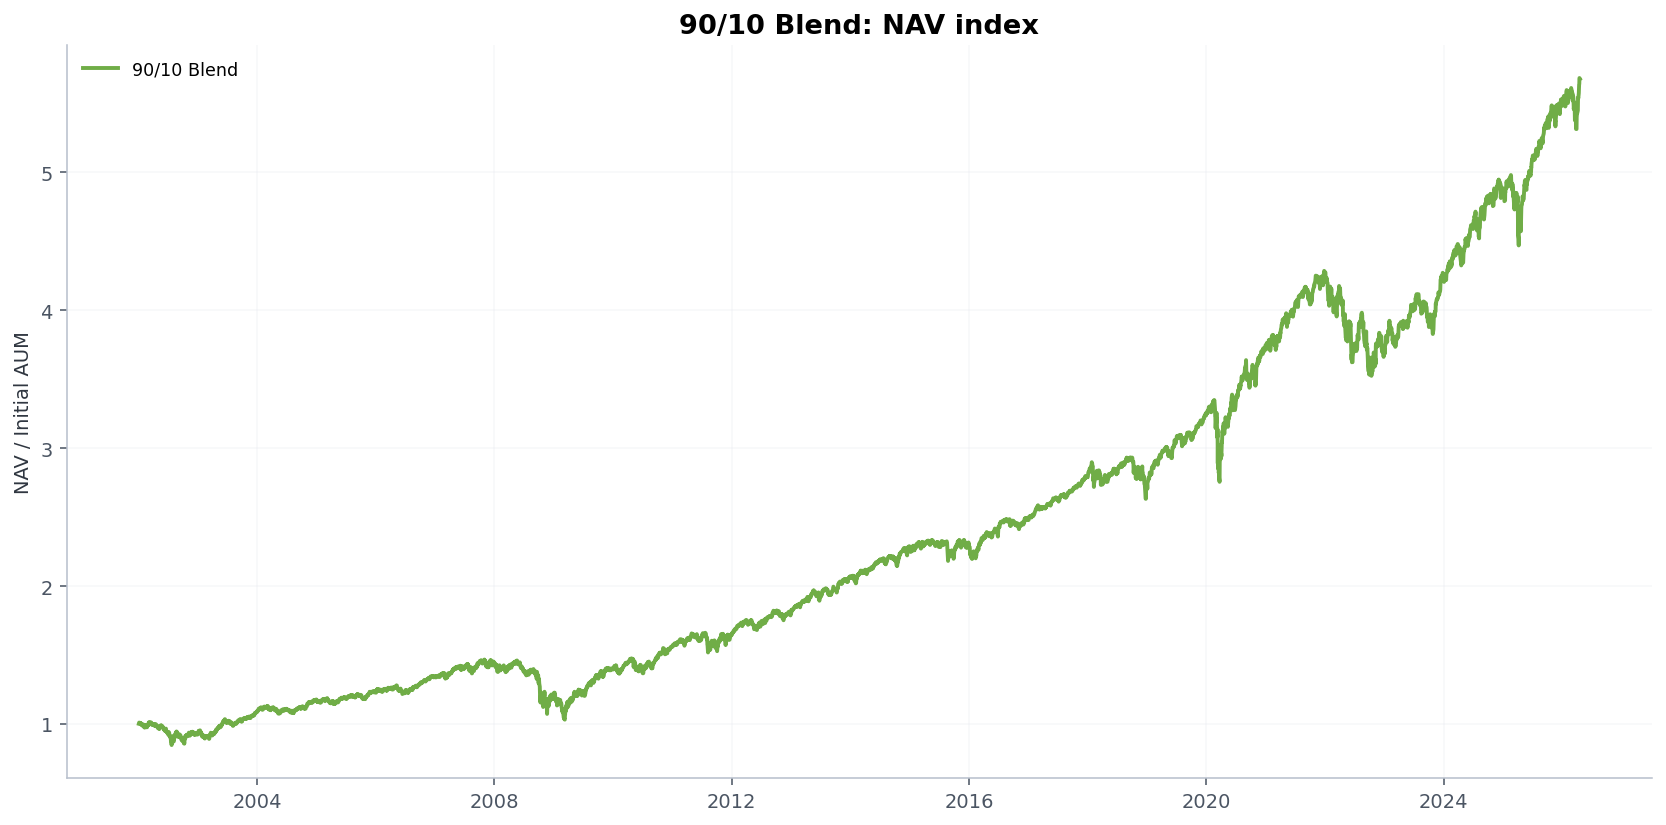

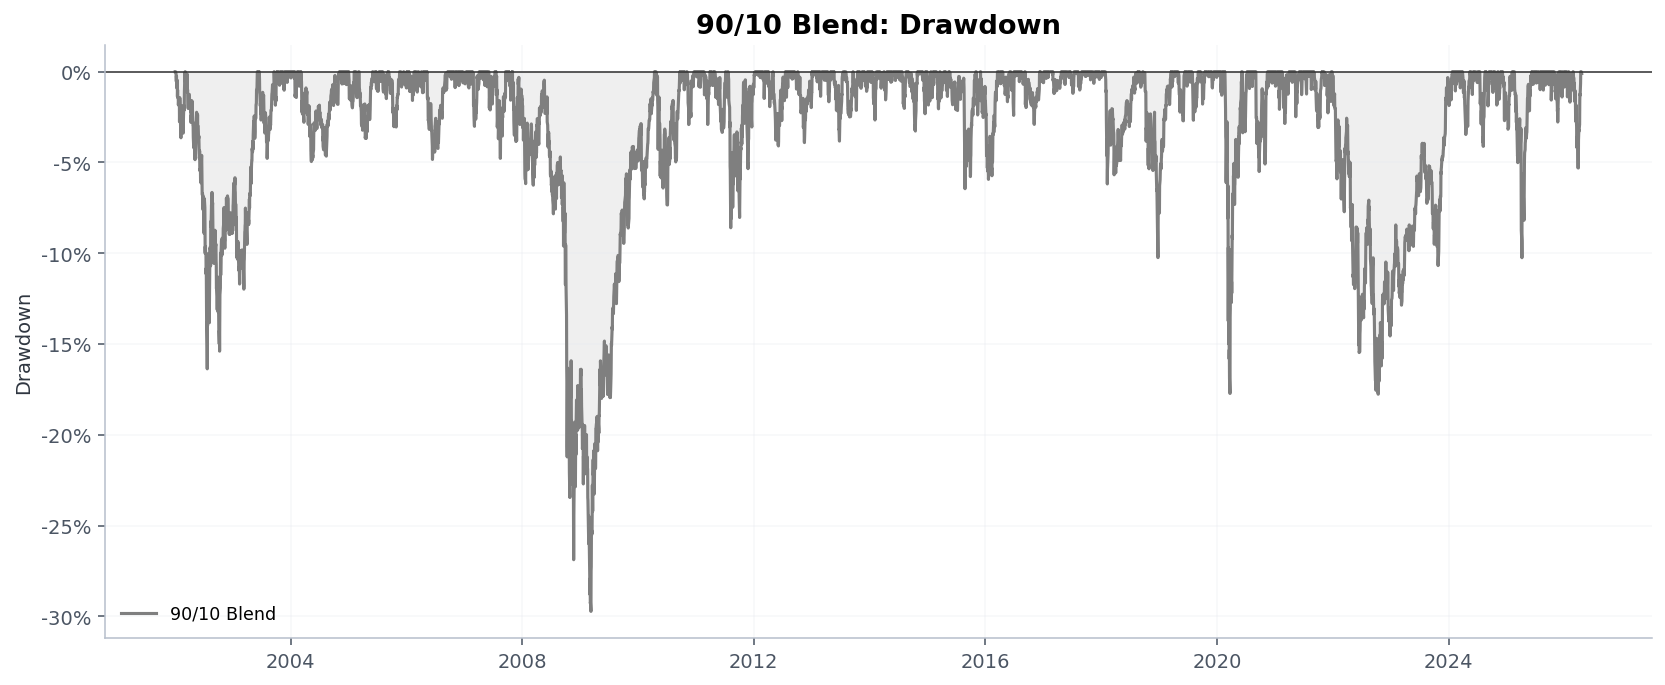

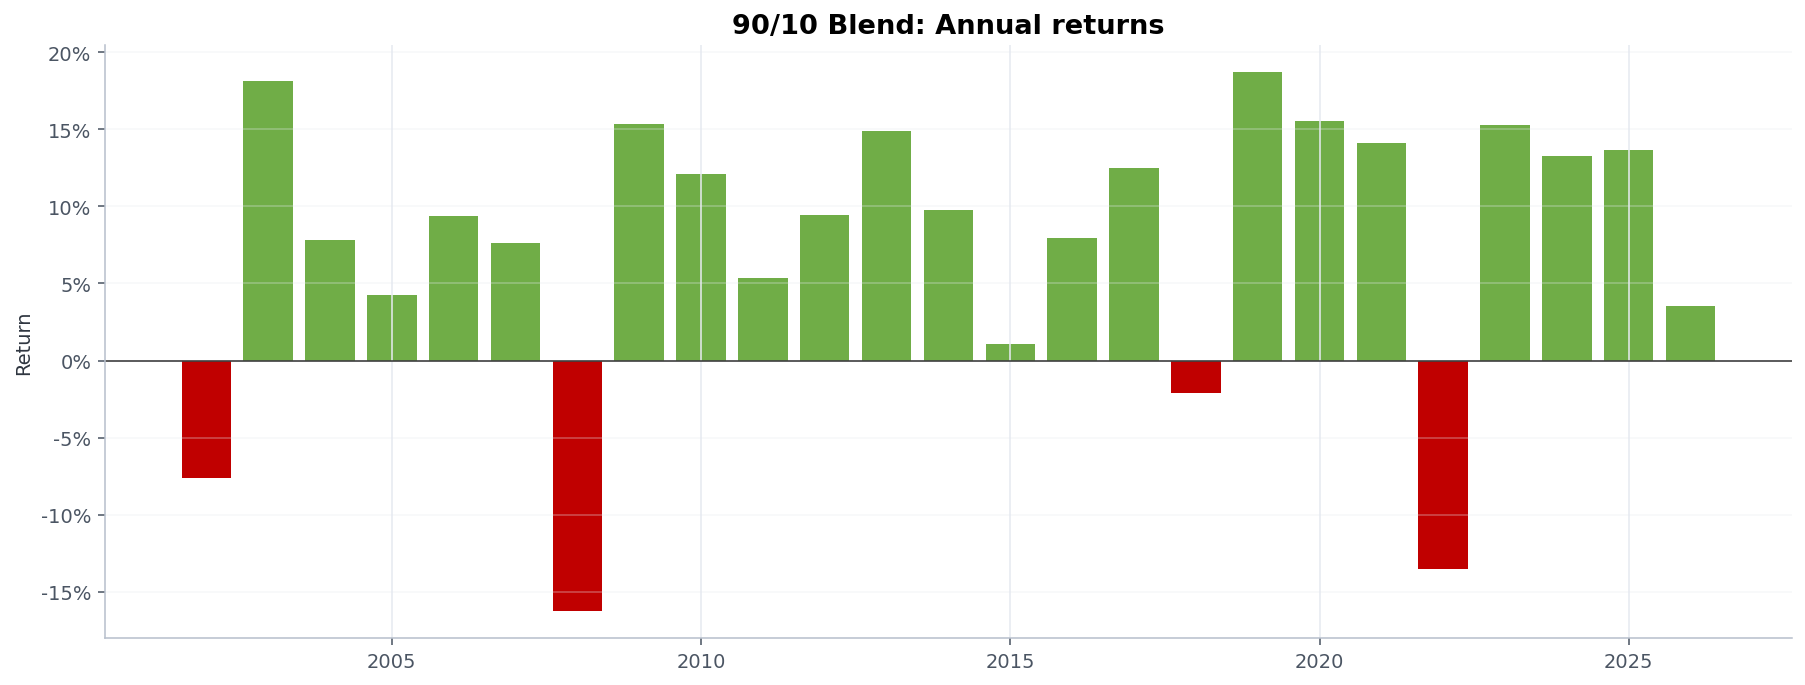

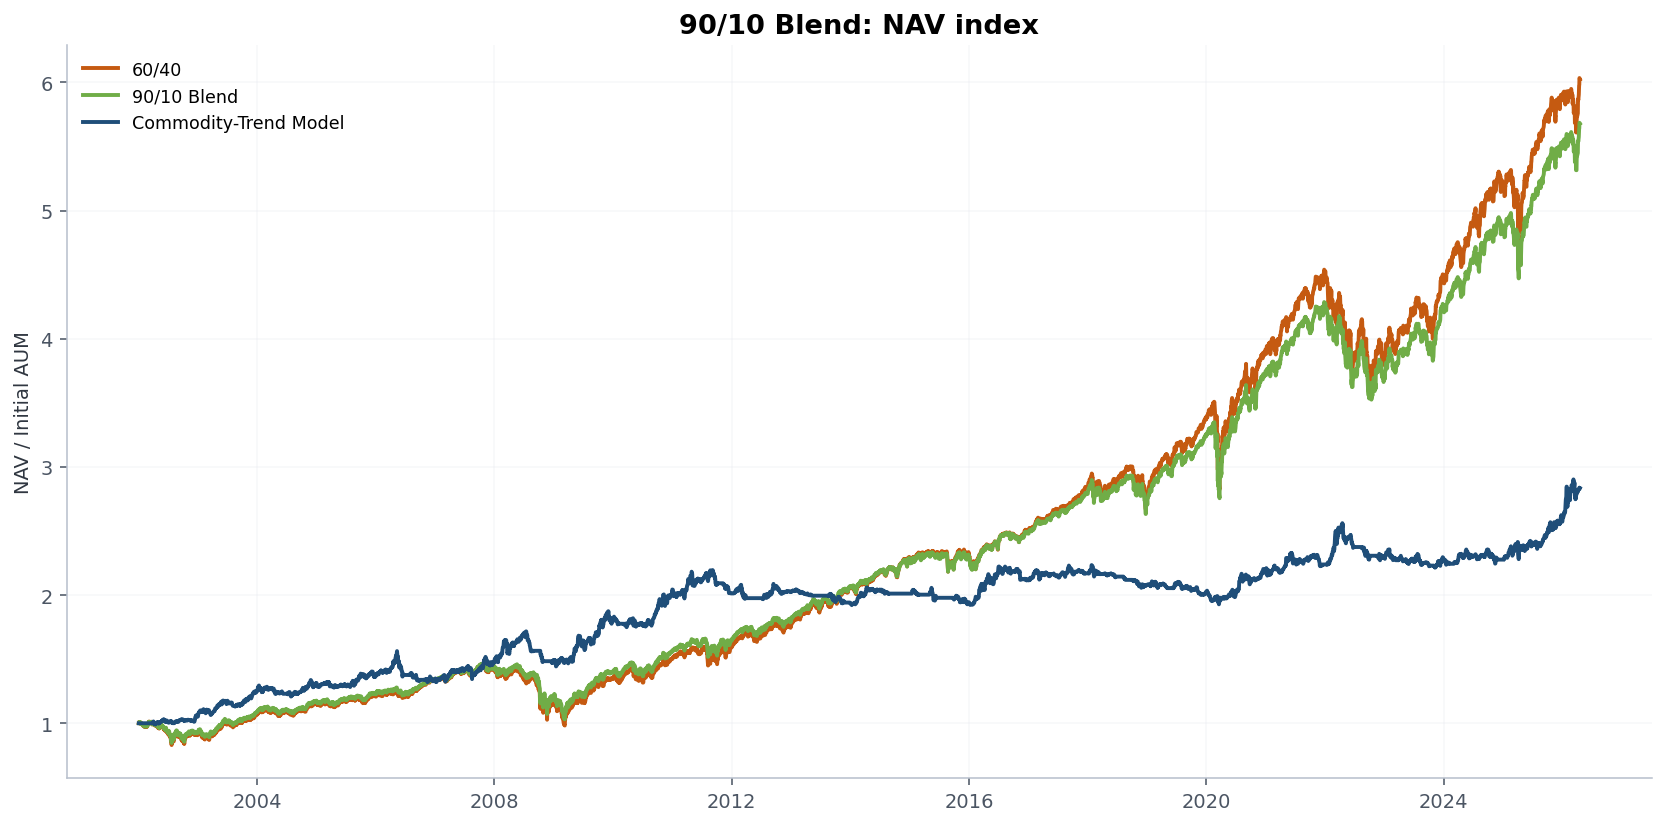

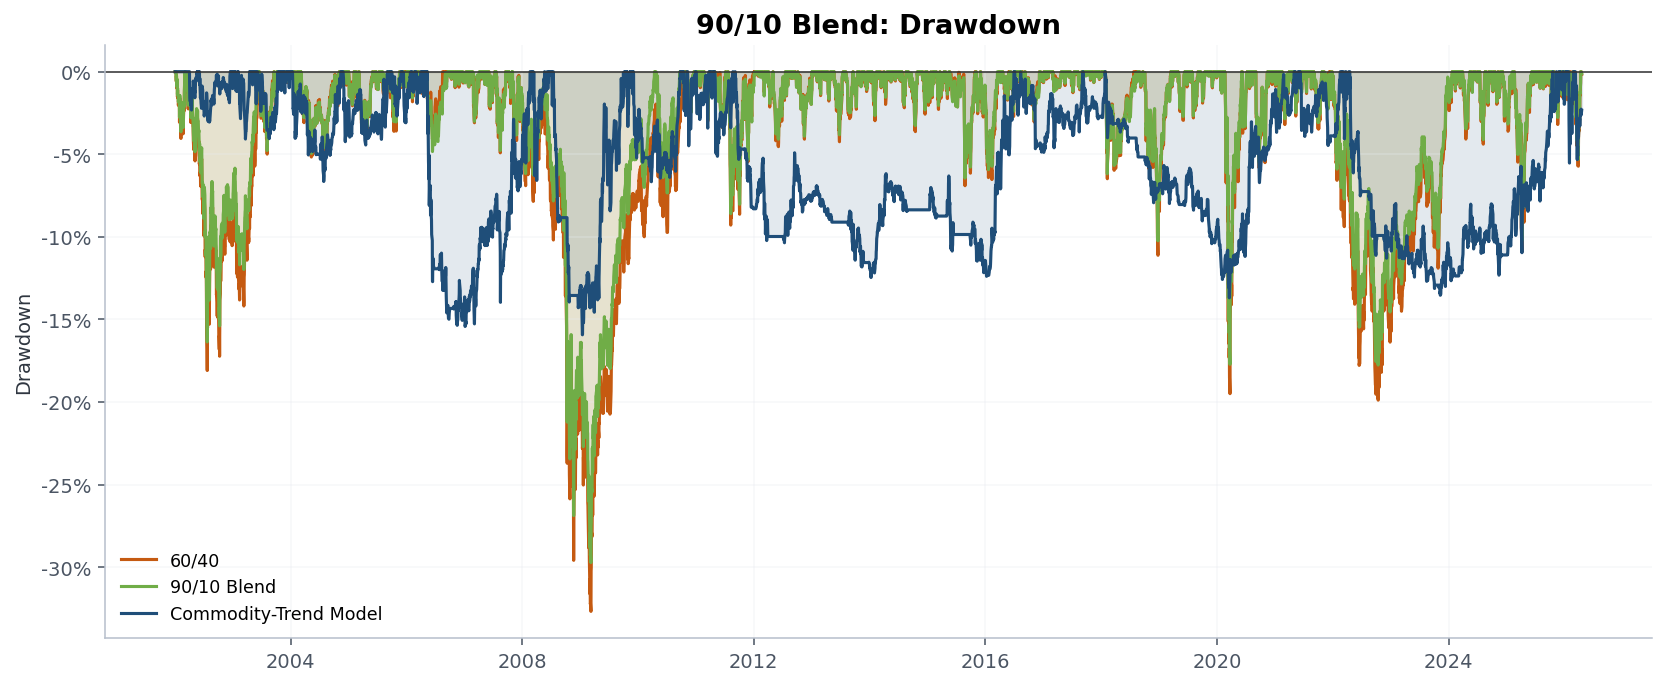

In [7]:
display_metric_table(sleeve_summary)
display_evaluation_block(SLEEVE_9010, strategy_returns[SLEEVE_9010], weight=0.10)
plot_nav_original(
    {BENCHMARK_6040: strategy_returns[BENCHMARK_6040], SLEEVE_9010: strategy_returns[SLEEVE_9010], COMMODITY_TREND: strategy_returns[COMMODITY_TREND]},
    "90/10 Blend: NAV index",
)
plot_drawdown_original(
    {BENCHMARK_6040: strategy_returns[BENCHMARK_6040], SLEEVE_9010: strategy_returns[SLEEVE_9010], COMMODITY_TREND: strategy_returns[COMMODITY_TREND]},
    "90/10 Blend: Drawdown",
)

A 10% Commodity-Trend sleeve raises Sharpe from 0.71 to 0.75, lowers vol from 10.87% to 9.92%, and improves max drawdown from -32.68% to -29.73%. Annual return falls slightly (7.67% to 7.41%), with ending NAV at $567.9M vs $602.5M on a $100M start.

,Metric,60/40,Commodity-Trend Model,90/10 Blend,Static MV,Dynamic MV
0,Start date,2002-01-02,2002-01-02,2002-01-02,2002-01-02,2002-01-02
1,End date,2026-04-20,2026-04-20,2026-04-20,2026-04-20,2026-04-20
2,Initial AUM,"$100,000,000","$100,000,000","$100,000,000","$100,000,000","$100,000,000"
3,Ending NAV,"$602,519,538","$283,449,790","$567,914,149","$413,197,949","$561,254,690"
4,Total return,502.04%,183.45%,467.51%,313.05%,460.85%
5,Annual rate of return,7.67%,4.38%,7.41%,6.01%,7.36%
6,Annualized volatility,10.87%,7.08%,9.92%,6.69%,7.95%
7,"Sharpe ratio, rf=0",0.71,0.62,0.75,0.90,0.93
8,Maximum drawdown,-32.68%,-15.93%,-29.73%,-19.41%,-18.33%
9,Maximum drawdown start,2007-10-09,2008-07-14,2007-10-31,2008-05-16,2008-05-16


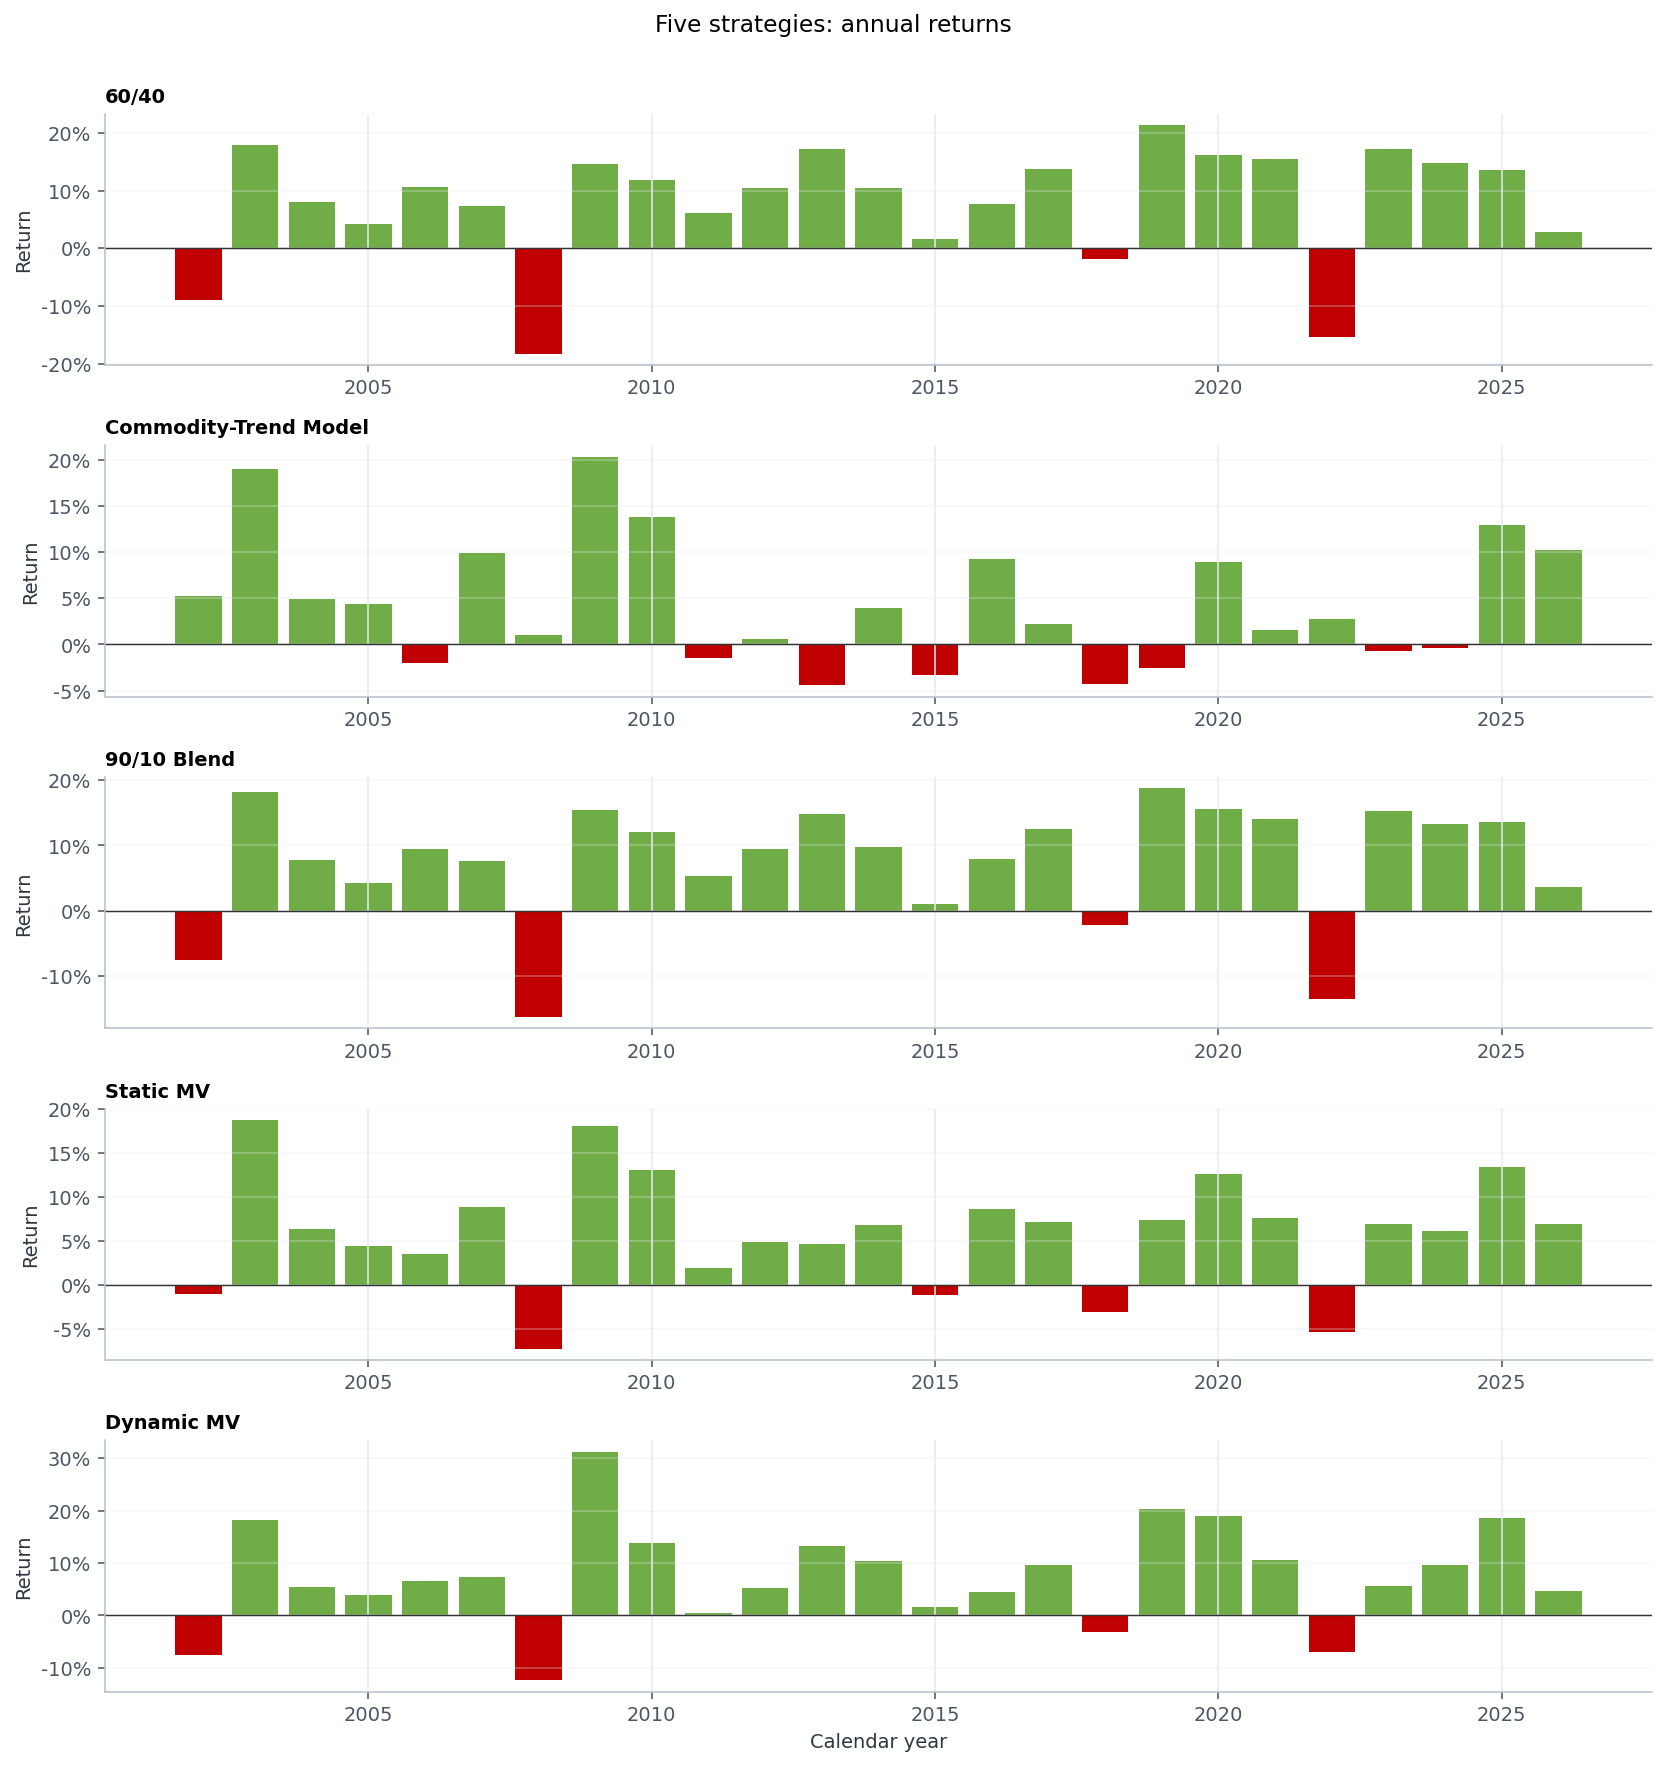

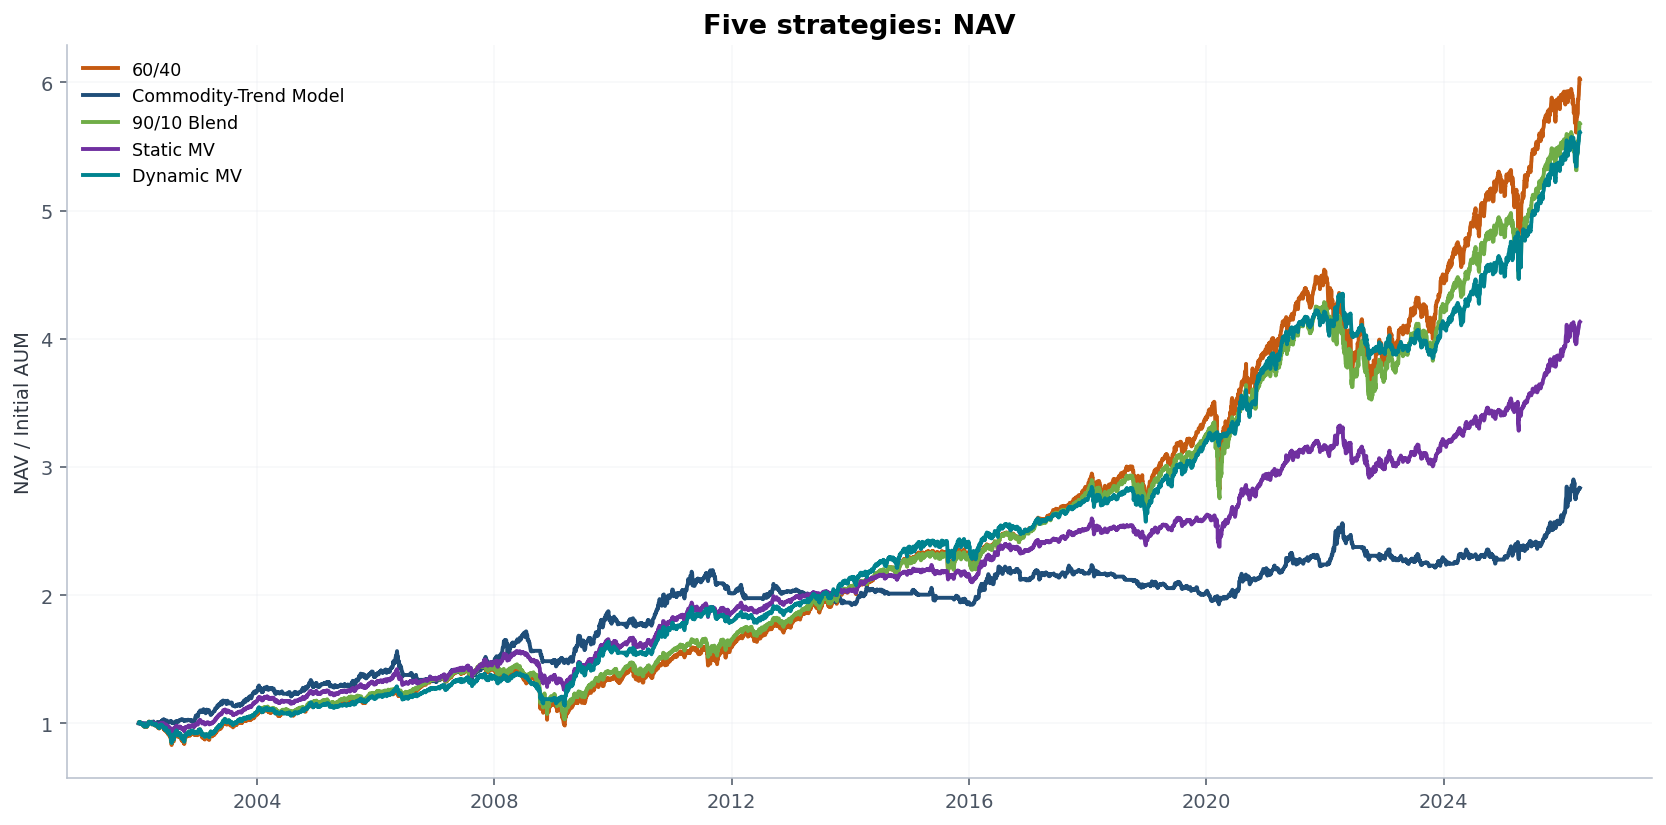

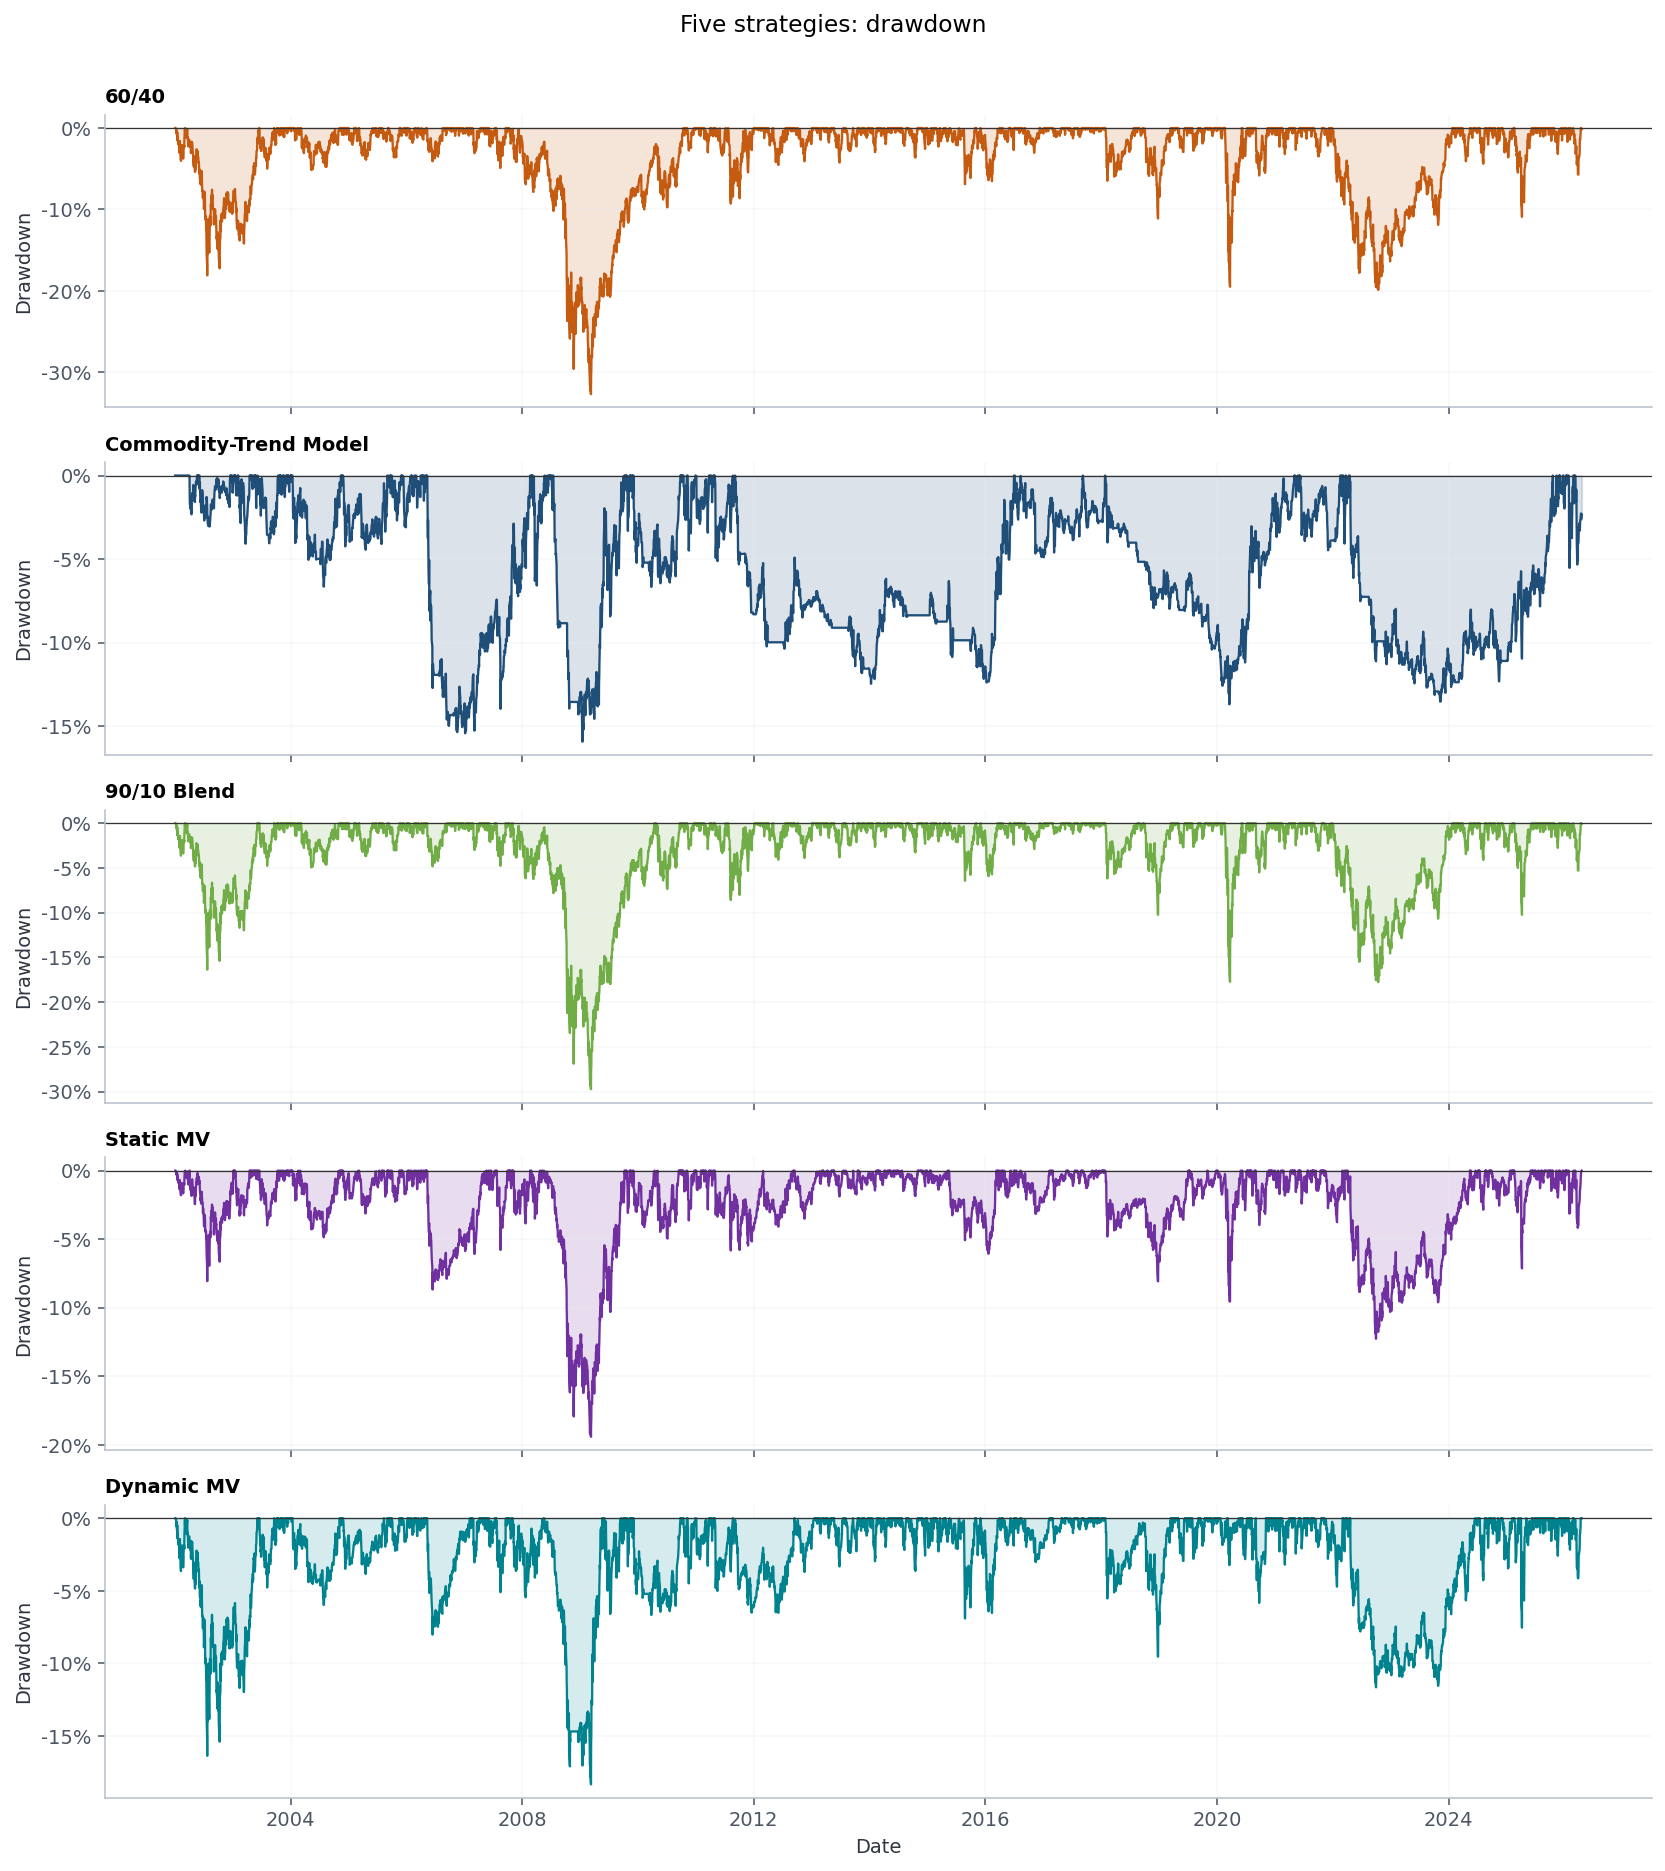

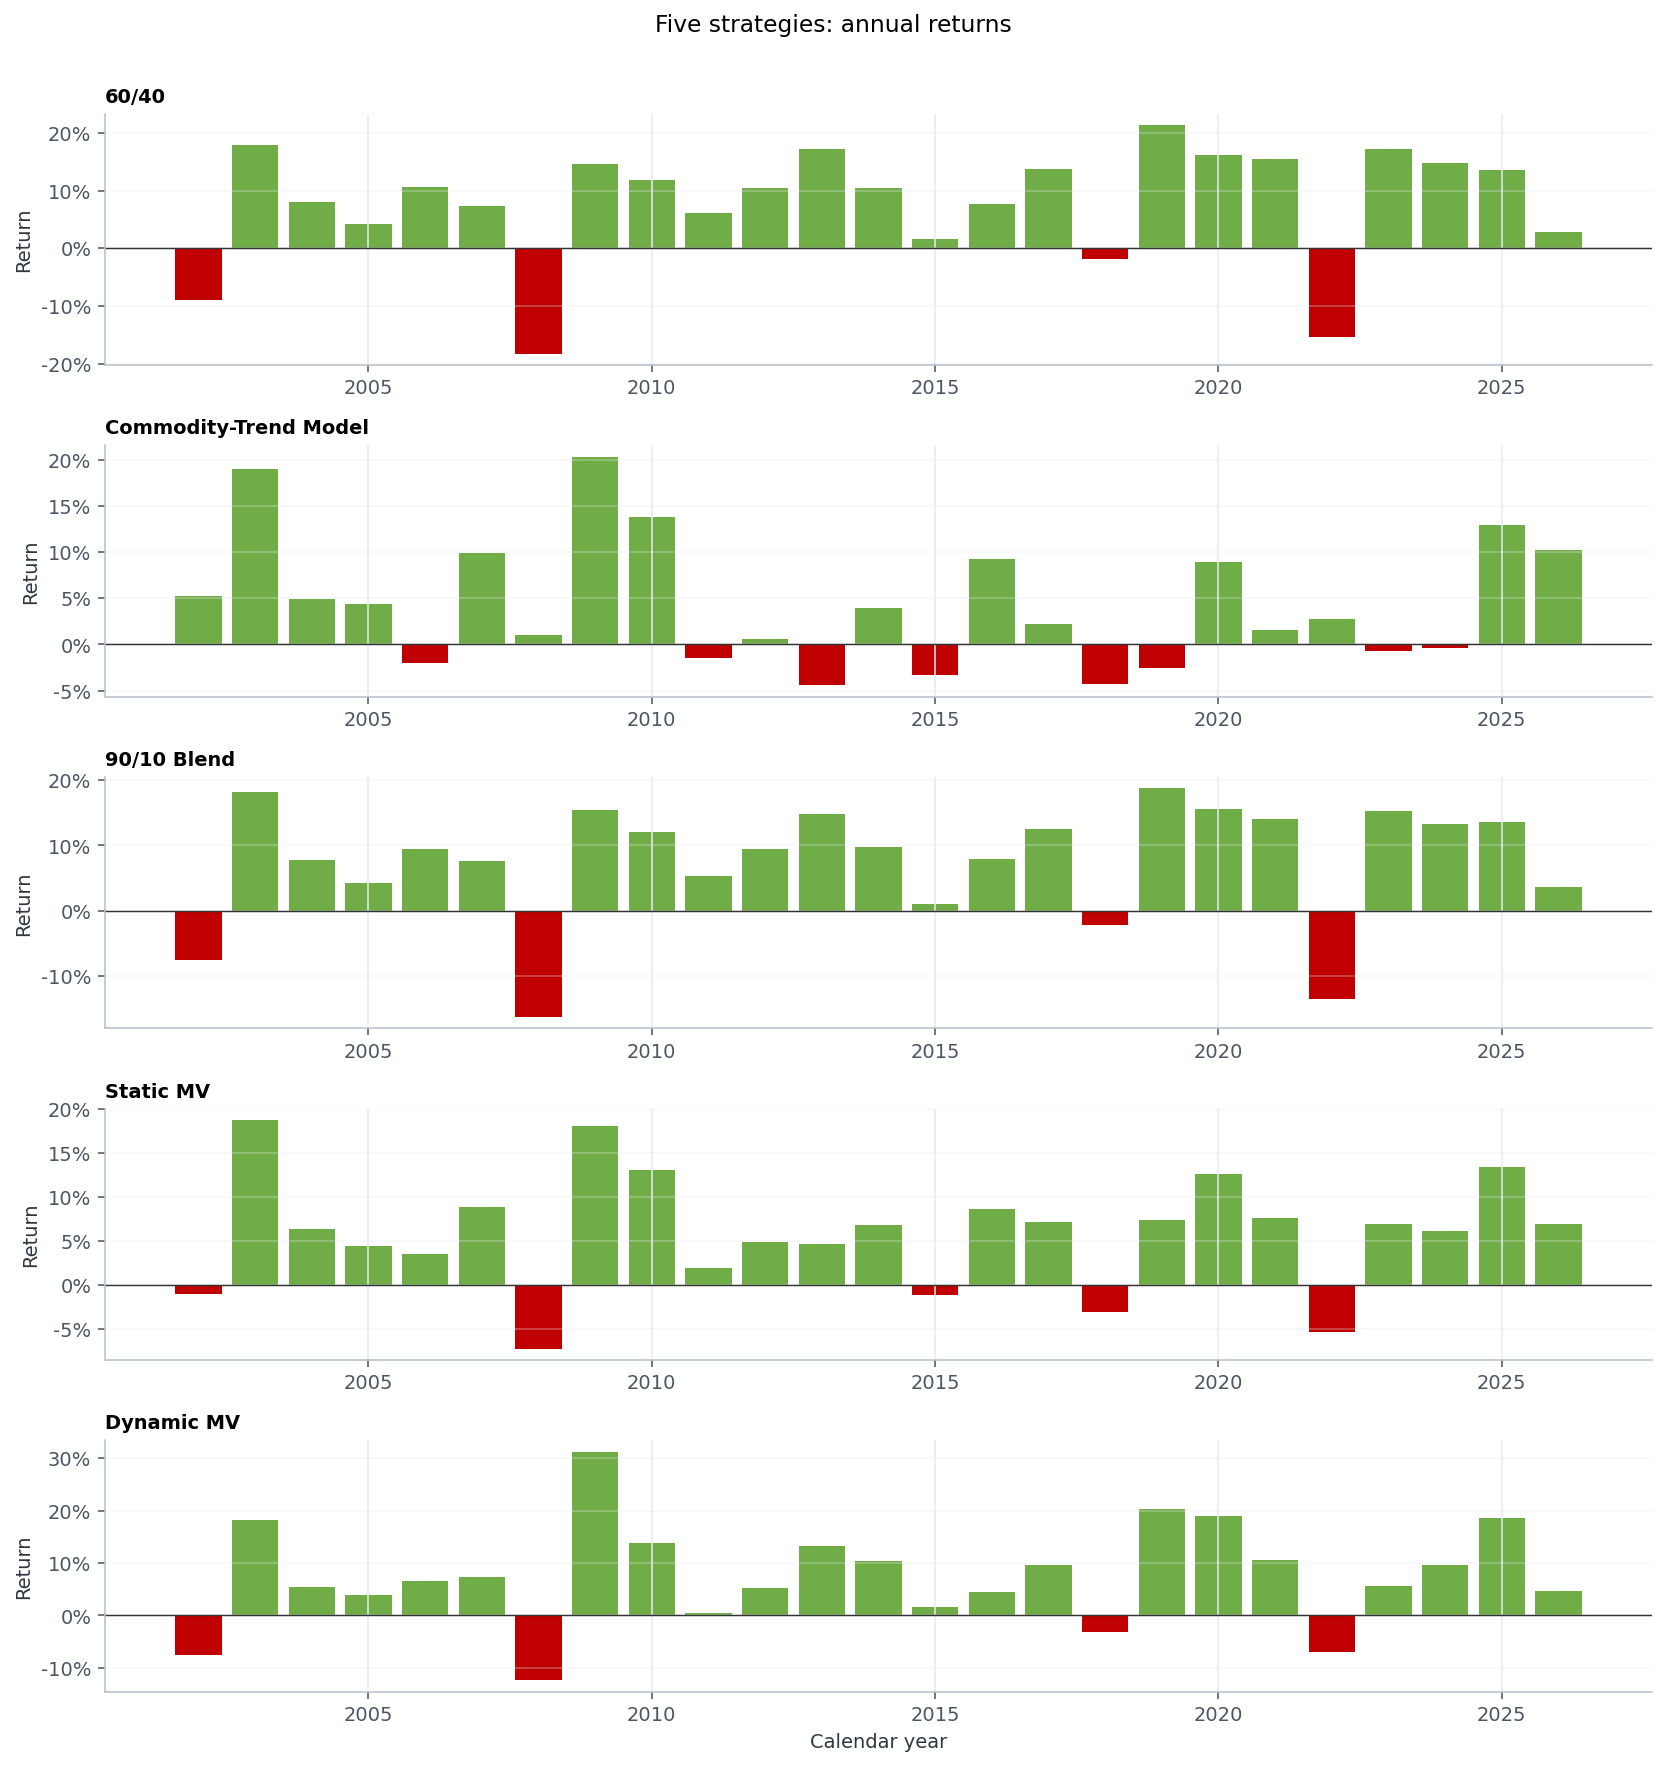

In [8]:
display_metric_table(five_strategy_summary)
plot_nav_original(
    {name: strategy_returns[name] for name in [BENCHMARK_6040, COMMODITY_TREND, SLEEVE_9010, STATIC_MV, DYNAMIC_MV]},
    "Five strategies: NAV",
)
plot_stacked_drawdowns_original(strategy_returns)
plot_stacked_annual_returns_original(strategy_returns)

Sharpe improves with larger trend weights: 0.71 (60/40), 0.75 (90/10 blend), 0.90 (static MV), 0.93 (dynamic MV). Dynamic MV earned 7.36% annualized vs 7.67% for 60/40, with 7.95% vol vs 10.87% and a -18.33% max drawdown vs -32.68%.

,Strategy,w_T,w_B,ann_return,ann_vol,sharpe
0,Tangency (long-only),0.559263,0.440737,0.058646,0.066888,0.876779
1,Min-variance (long-only),0.736602,0.263398,0.052727,0.063423,0.831353
2,90/10 sleeve,0.100000,0.900000,0.073976,0.099205,0.745685
3,60/40 only,0.000000,1.000000,0.077314,0.108690,0.711325
4,Commodity-Trend Model only,1.000000,0.000000,0.043935,0.070842,0.620174


,Metric,Static MV
0,Strategy,Static MV
1,Start,2002-01-02
2,End,2026-04-20
3,Total Return,3.1320
4,Ann. Return,0.0580
5,Ann. Vol,0.0669
6,Sharpe,0.8674
7,Max Drawdown,-0.1941
8,Weights (w_T / w_B),56% / 44%


Month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
Year,,,,,,,,,,,,,
2002,-0.2%,-0.3%,0.6%,-0.8%,1.0%,-2.5%,-1.8%,1.2%,-1.8%,2.1%,0.9%,0.8%,-1.0%
2003,1.9%,-0.4%,-0.5%,5.1%,2.9%,0.4%,-0.9%,0.5%,0.7%,3.0%,1.0%,3.8%,18.8%
2004,0.5%,2.0%,-0.5%,-2.7%,0.5%,0.2%,-1.2%,1.5%,1.0%,1.8%,2.7%,0.6%,6.4%
2005,-0.9%,1.0%,-1.4%,-0.6%,1.5%,-0.1%,1.0%,1.1%,2.6%,-1.8%,2.4%,-0.3%,4.4%
2006,2.2%,0.2%,0.5%,3.0%,-2.6%,-2.4%,0.5%,0.5%,-0.5%,1.1%,1.8%,-0.7%,3.5%
2007,0.4%,0.4%,1.2%,2.3%,1.0%,-0.4%,0.0%,-1.2%,2.9%,3.5%,-2.2%,0.8%,8.9%
2008,0.8%,3.1%,-2.3%,2.7%,1.5%,-0.4%,-2.1%,-1.9%,-2.1%,-7.0%,-0.7%,1.4%,-7.2%
2009,-3.1%,-2.7%,2.4%,3.5%,6.4%,-0.5%,2.7%,0.6%,3.9%,1.0%,4.4%,-1.4%,18.1%
2010,-1.4%,1.1%,1.3%,2.0%,-3.3%,-0.7%,2.4%,-1.2%,6.0%,2.4%,-0.2%,4.3%,13.1%


,Metric,Dynamic MV
0,Strategy,Dynamic MV
1,Start,2002-01-02
2,End,2026-04-20
3,Total Return,4.6125
4,Ann. Return,0.0710
5,Ann. Vol,0.0795
6,Sharpe,0.8928
7,Max Drawdown,-0.1833


Month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
Year,,,,,,,,,,,,,
2002,-0.5%,-0.7%,1.2%,-2.4%,0.0%,-3.5%,-3.3%,1.4%,-4.9%,4.4%,2.8%,-1.9%,-7.6%
2003,-1.0%,-0.2%,0.3%,5.1%,4.1%,0.5%,-0.7%,1.3%,0.6%,2.8%,0.7%,3.5%,18.1%
2004,-0.1%,2.4%,-0.4%,-2.9%,0.3%,-0.5%,-1.1%,1.7%,1.1%,2.0%,3.1%,-0.3%,5.4%
2005,-0.8%,1.0%,-1.5%,-0.7%,1.2%,-0.3%,1.0%,1.2%,2.5%,-1.8%,2.3%,-0.3%,3.8%
2006,2.1%,0.2%,0.5%,2.5%,-2.5%,-2.0%,0.7%,0.9%,0.5%,1.7%,1.6%,0.2%,6.5%
2007,0.7%,-0.3%,0.8%,2.7%,1.5%,-0.8%,-0.7%,0.4%,2.6%,1.9%,-1.6%,0.0%,7.2%
2008,-1.3%,1.1%,-2.1%,2.6%,1.3%,-1.0%,-2.4%,-2.1%,-2.8%,-6.7%,0.0%,0.6%,-12.4%
2009,-0.7%,0.3%,6.4%,4.1%,9.2%,-1.0%,1.2%,-1.0%,4.9%,2.7%,4.6%,-2.6%,31.2%
2010,-1.4%,0.3%,-0.2%,2.5%,-2.7%,0.6%,0.8%,-0.6%,6.5%,2.6%,-0.1%,5.1%,13.8%


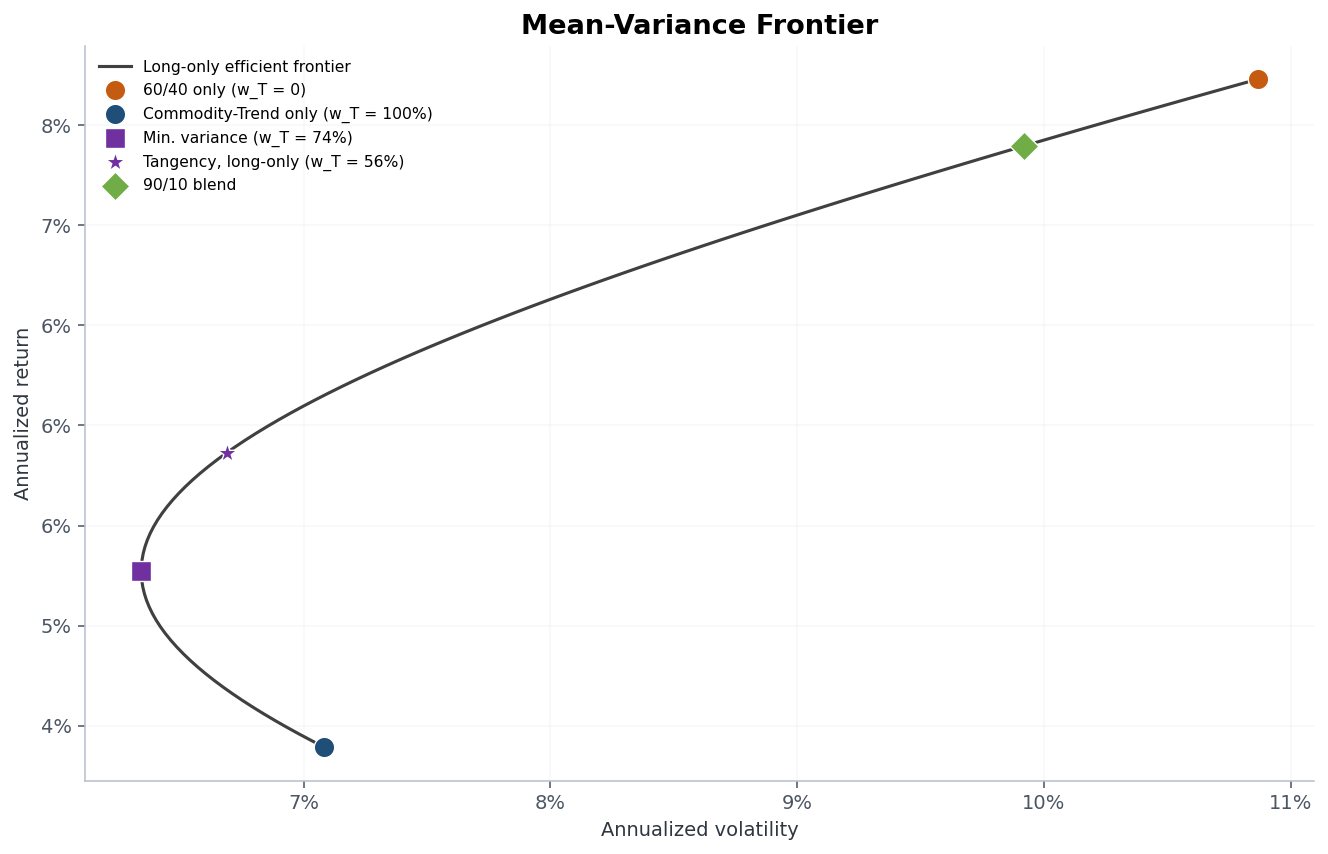

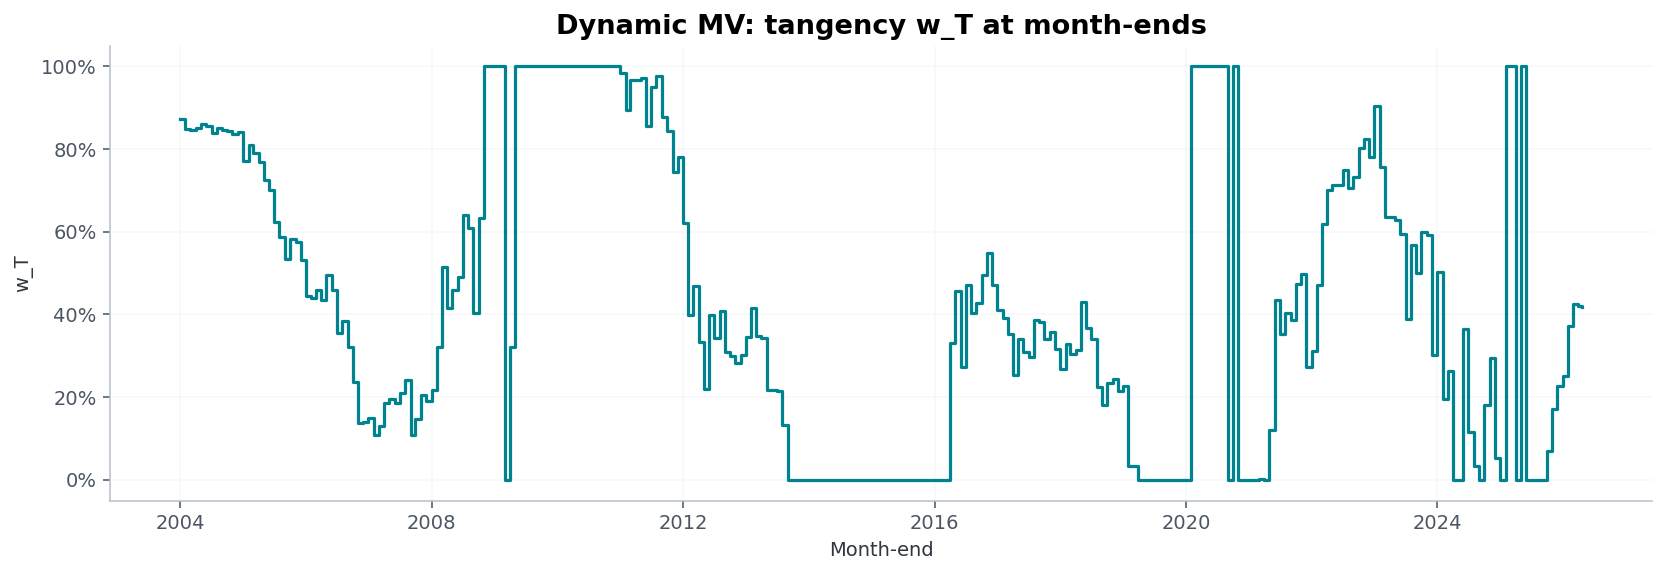

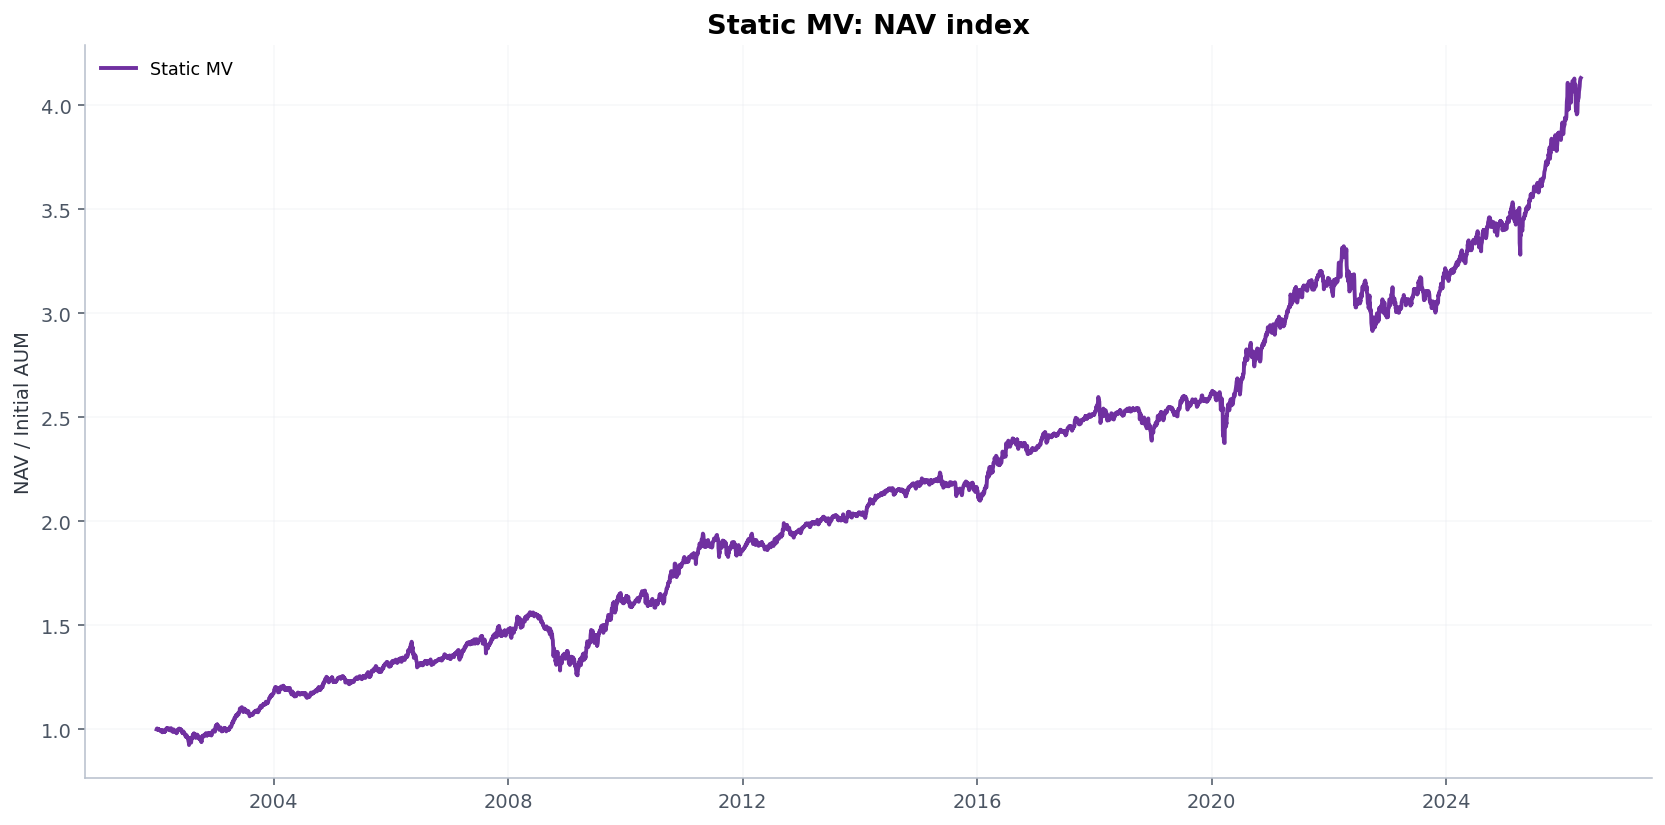

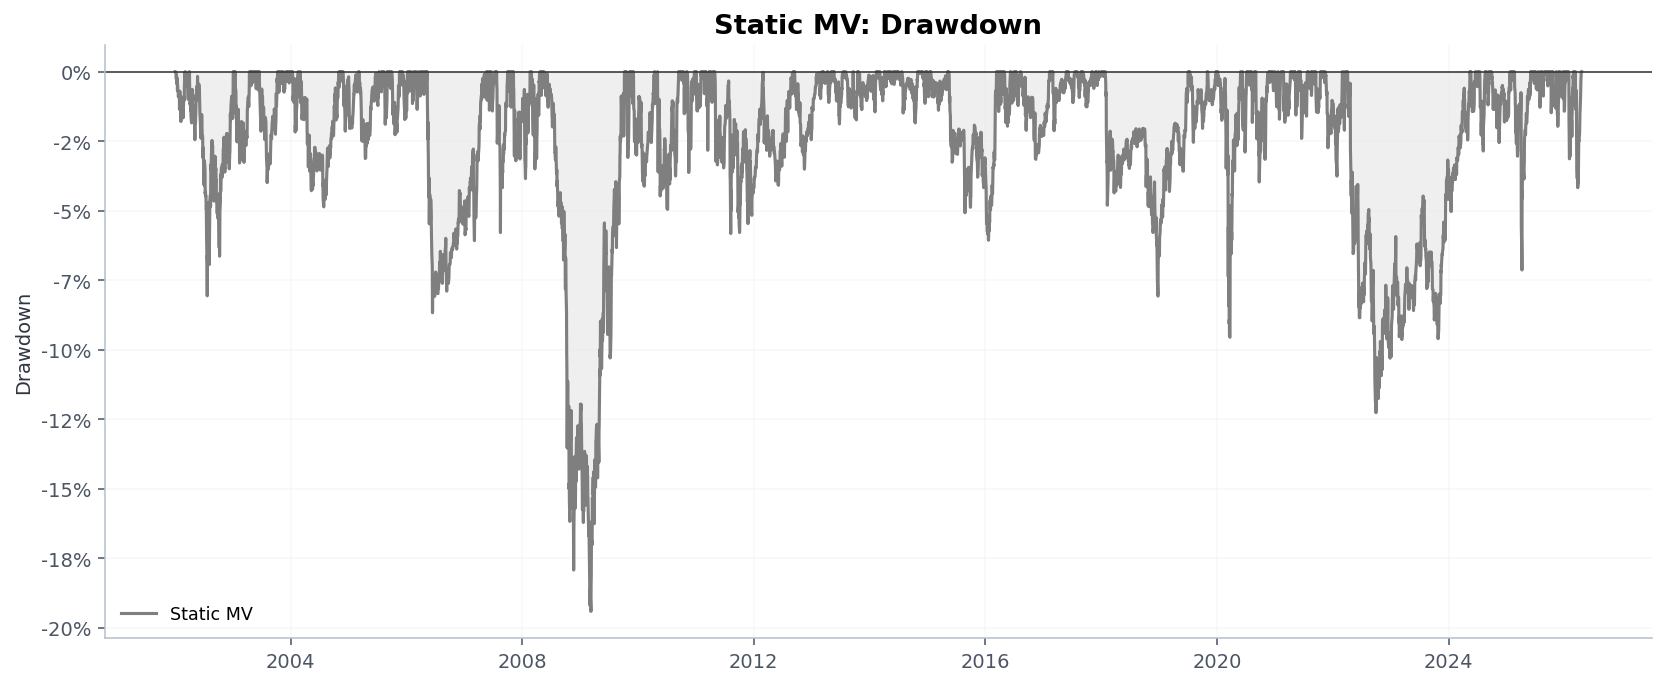

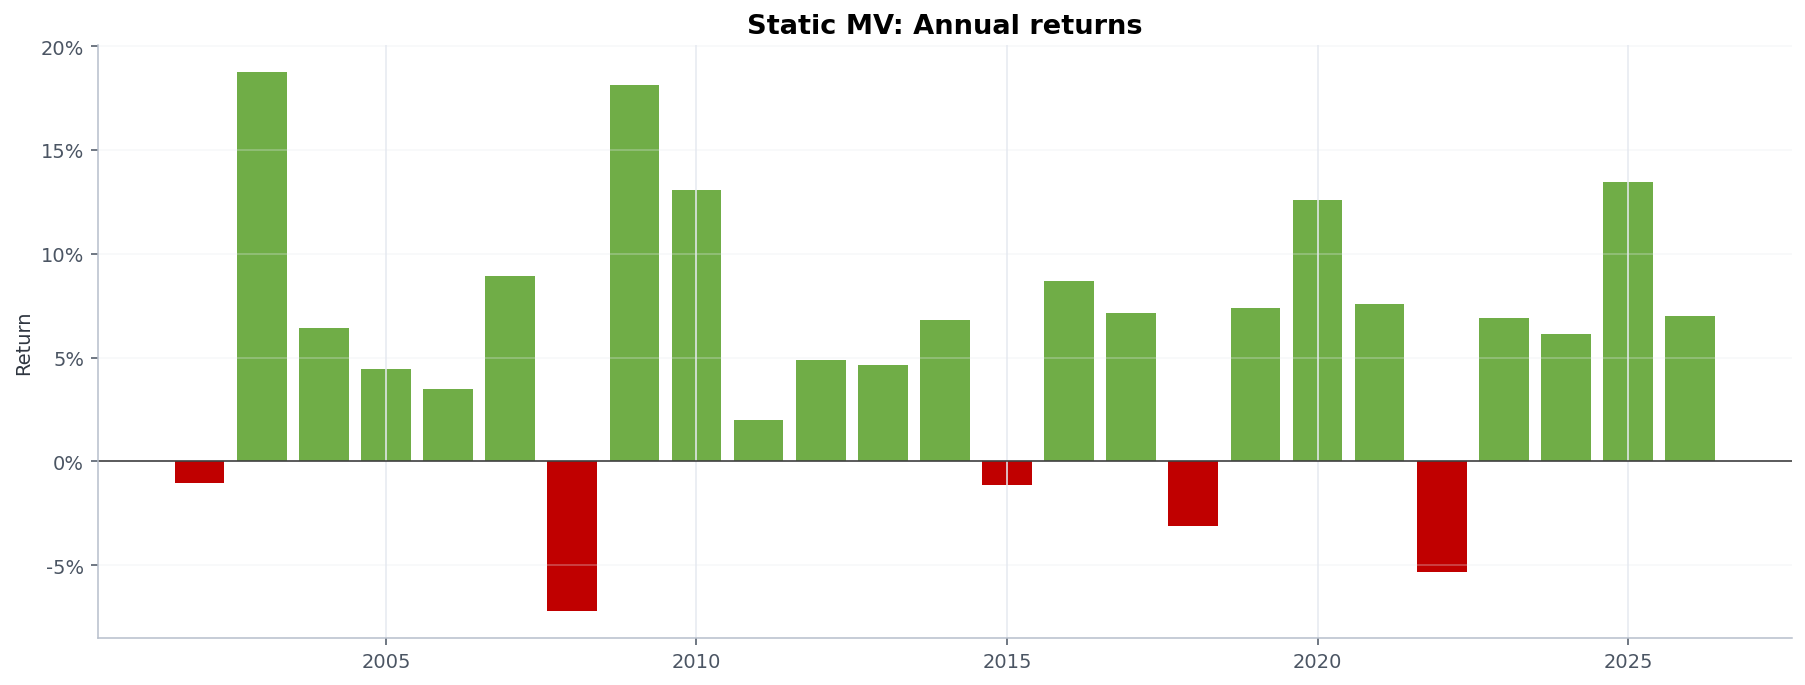

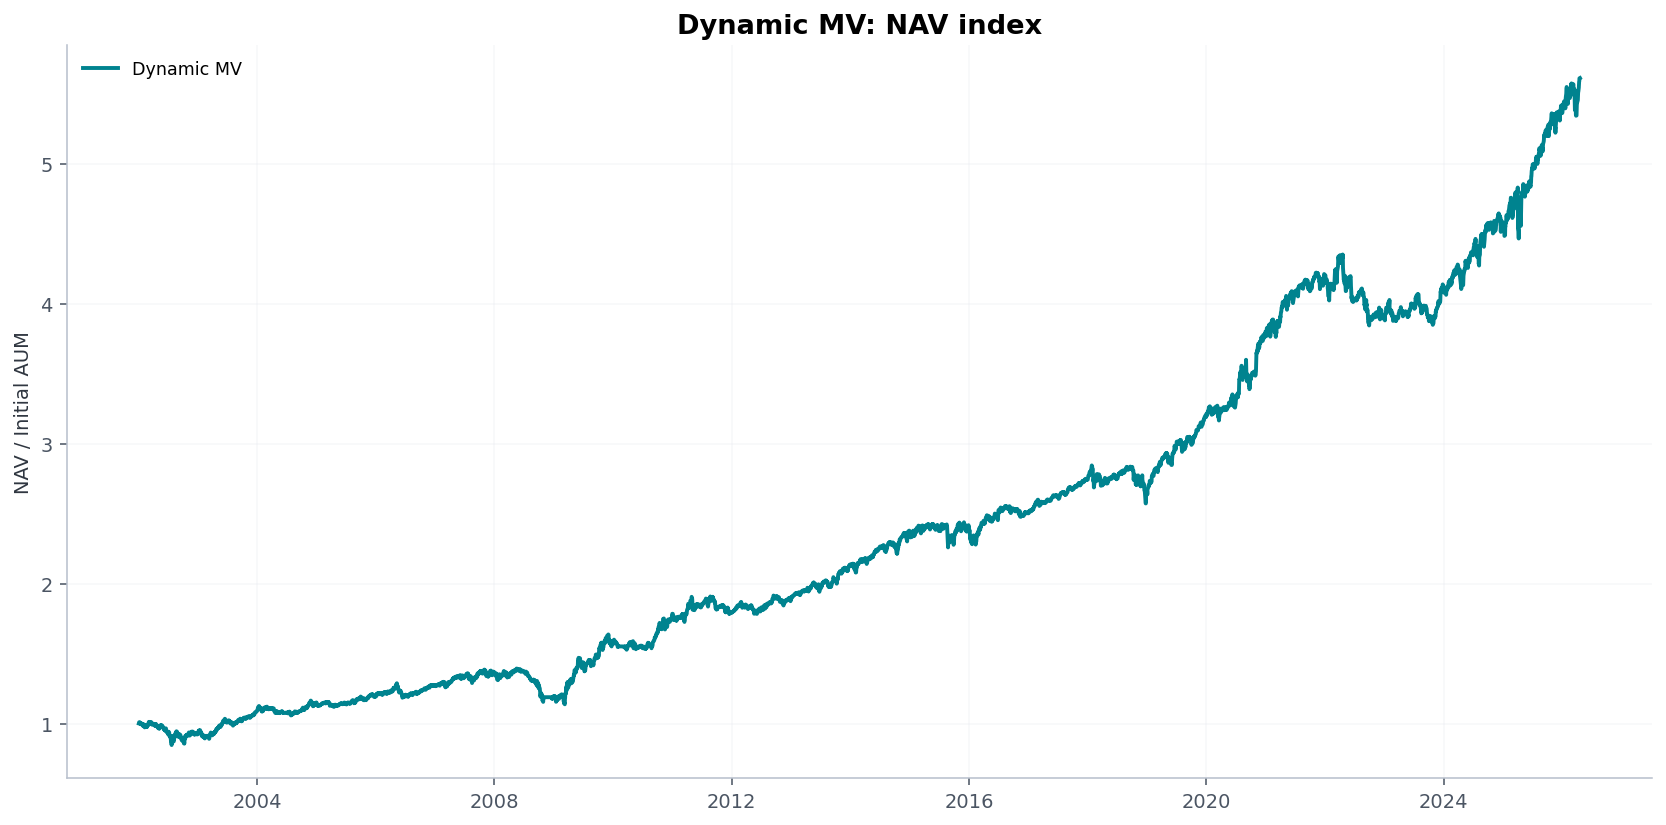

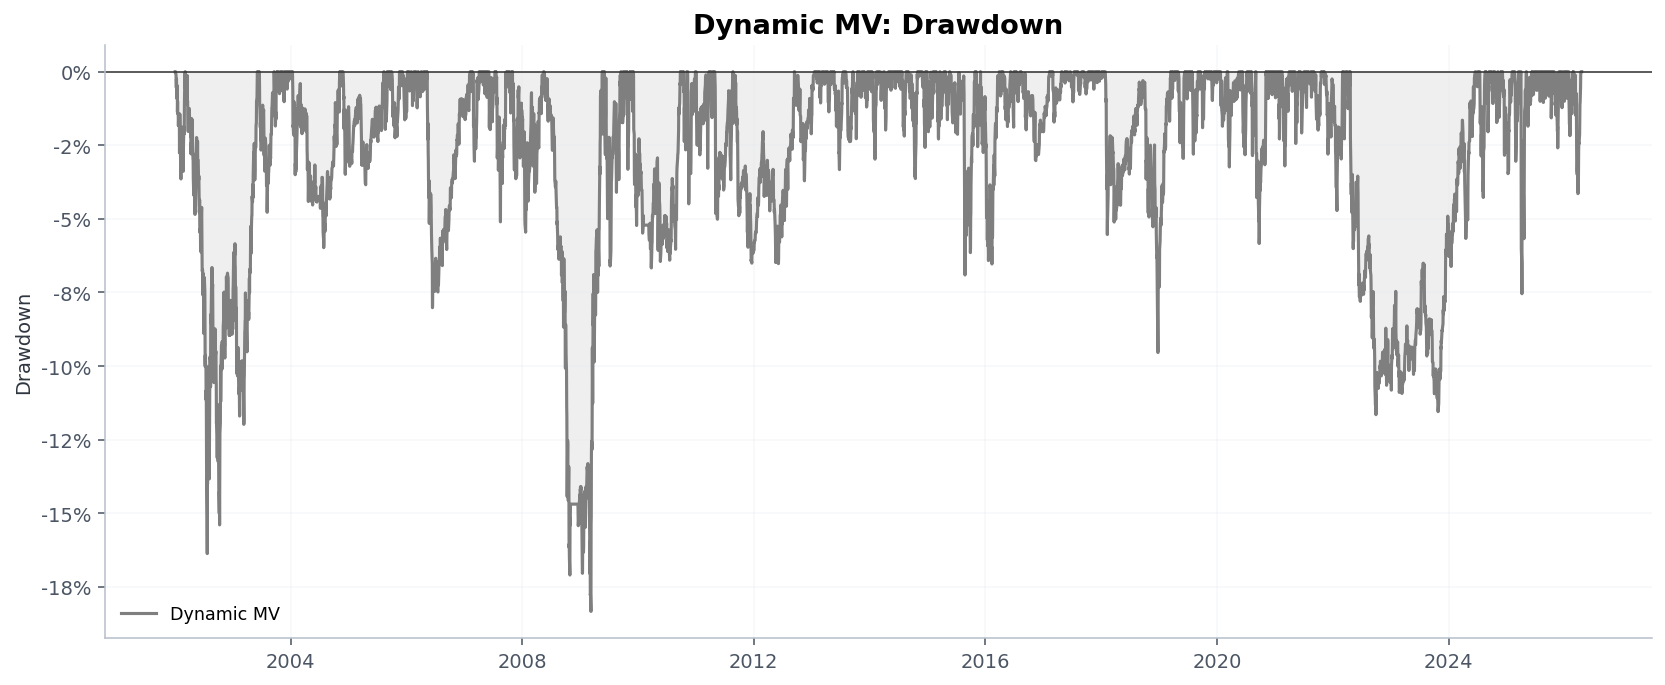

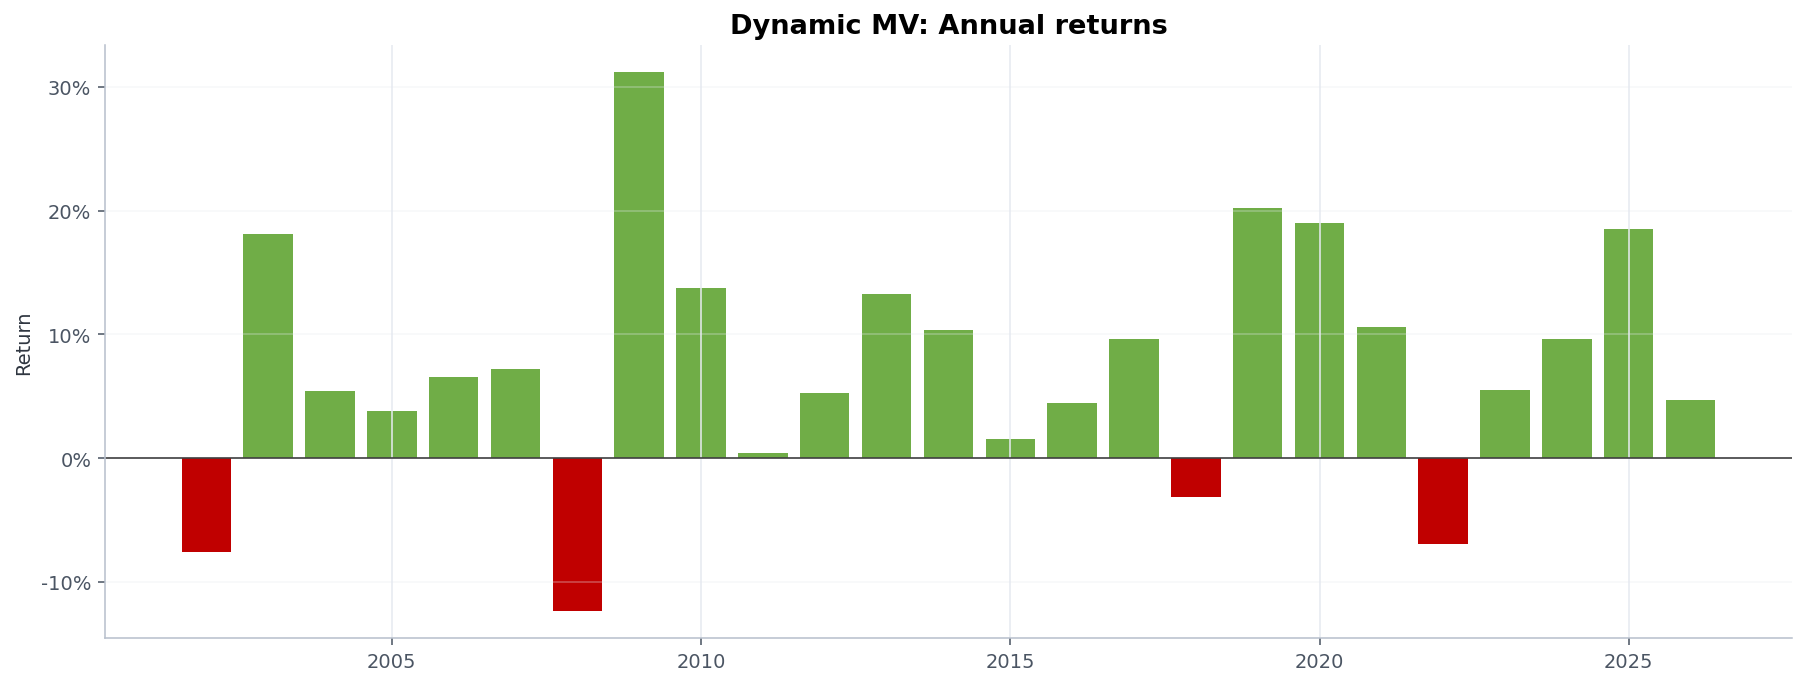

In [9]:
display_metric_table(static_mv_weights)
plot_mean_variance_frontier_original(core_returns, static_mv_weights)
plot_dynamic_weight_step(dynamic_weights)
display_evaluation_block(STATIC_MV, strategy_returns[STATIC_MV], weight=float(static_mv_weights.loc[static_mv_weights["Strategy"].str.contains("Tangency", case=False), "w_T"].iloc[0]))
display_evaluation_block(DYNAMIC_MV, strategy_returns[DYNAMIC_MV])

The static tangency portfolio holds 56% Commodity-Trend / 44% 60/40 (Sharpe 0.88); the minimum-variance portfolio holds 73.7% Commodity-Trend. The dynamic tangency weight ranged from 0% to 100% over the sample and ended at 41.8% in April 2026, so the optimal weight is very sensitive to the historical window.

## Part 4 — 60/40 Drawdowns

These exhibits focus on how the Commodity-Trend Model behaved when the 60/40 benchmark was under pressure.

Peak Date,Trough Date,Recovery Date,Depth 60 40,Large Ge 10Pct,Len Peak To Trough Days,Len Peak To Recovery Days,Bench Ret Peak To Trough,Bench Ret Peak To Recovery,Trend Ret Peak To Trough,Trend Ret Peak To Recovery,Trend Max Dd Peak To Trough,Trend Hit Rate Peak To Trough
2007-10-09 00:00:00,2009-03-09 00:00:00,2010-10-18 00:00:00,-0.33,True,370,790,-0.32,0.01,0.05,0.38,-0.16,43.8%
2021-12-27 00:00:00,2022-10-14 00:00:00,2024-01-25 00:00:00,-0.20,True,210,544,-0.19,0.01,0.03,0.00,-0.11,41.4%
2020-02-19 00:00:00,2020-03-23 00:00:00,2020-06-05 00:00:00,-0.19,True,24,78,-0.19,0.00,-0.01,0.03,-0.03,58.3%
2002-03-06 00:00:00,2002-07-23 00:00:00,2003-06-16 00:00:00,-0.18,True,100,334,-0.17,0.01,0.01,0.17,-0.03,42.0%
2018-09-21 00:00:00,2018-12-24 00:00:00,2019-03-15 00:00:00,-0.11,True,67,126,-0.11,0.00,-0.02,-0.02,-0.03,40.3%
2025-02-19 00:00:00,2025-04-08 00:00:00,2025-06-10 00:00:00,-0.11,True,35,80,-0.11,0.00,-0.04,0.01,-0.06,51.4%
2011-07-22 00:00:00,2011-08-08 00:00:00,2012-01-03 00:00:00,-0.09,False,12,118,-0.09,0.01,-0.02,-0.06,-0.03,41.7%
2015-05-21 00:00:00,2015-08-25 00:00:00,2015-10-28 00:00:00,-0.07,False,69,115,-0.07,0.00,-0.02,-0.02,-0.03,8.7%
2015-12-01 00:00:00,2016-02-11 00:00:00,2016-03-29 00:00:00,-0.07,False,53,86,-0.06,0.01,0.02,0.06,-0.02,49.1%
2018-01-26 00:00:00,2018-02-08 00:00:00,2018-07-25 00:00:00,-0.06,False,10,129,-0.06,0.01,-0.04,-0.04,-0.03,10.0%


<Axes: title={'center': 'Deepest 13 drawdown episodes: peak-to-trough returns'}, xlabel='Return'>

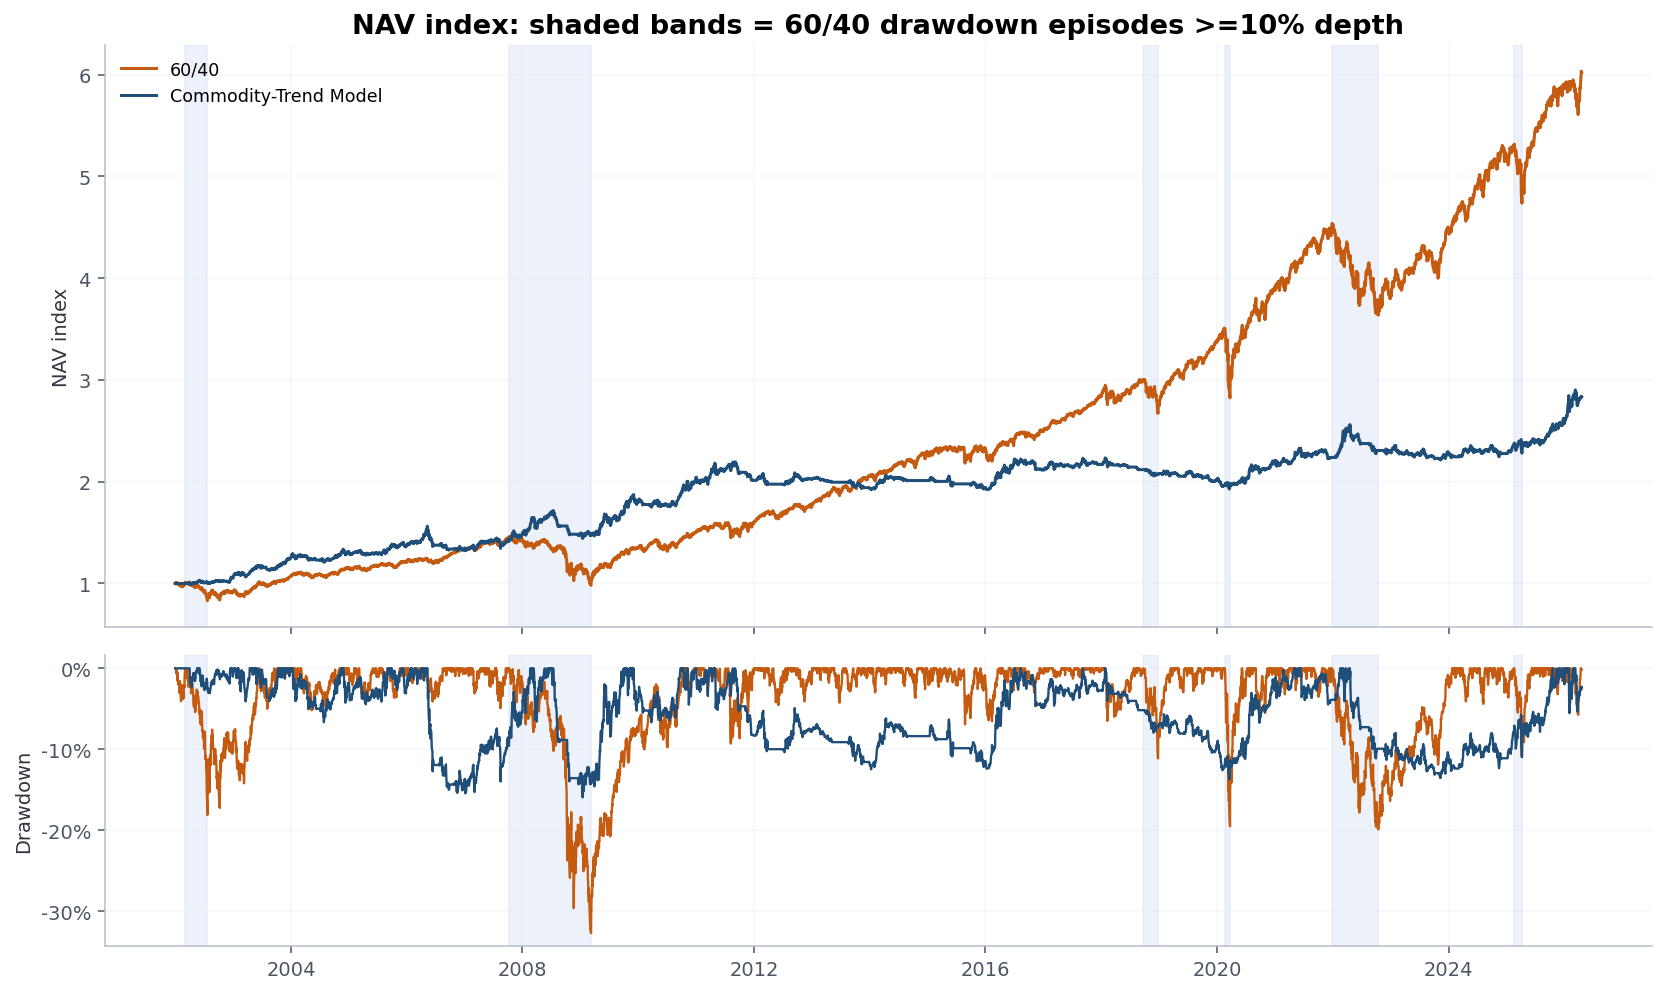

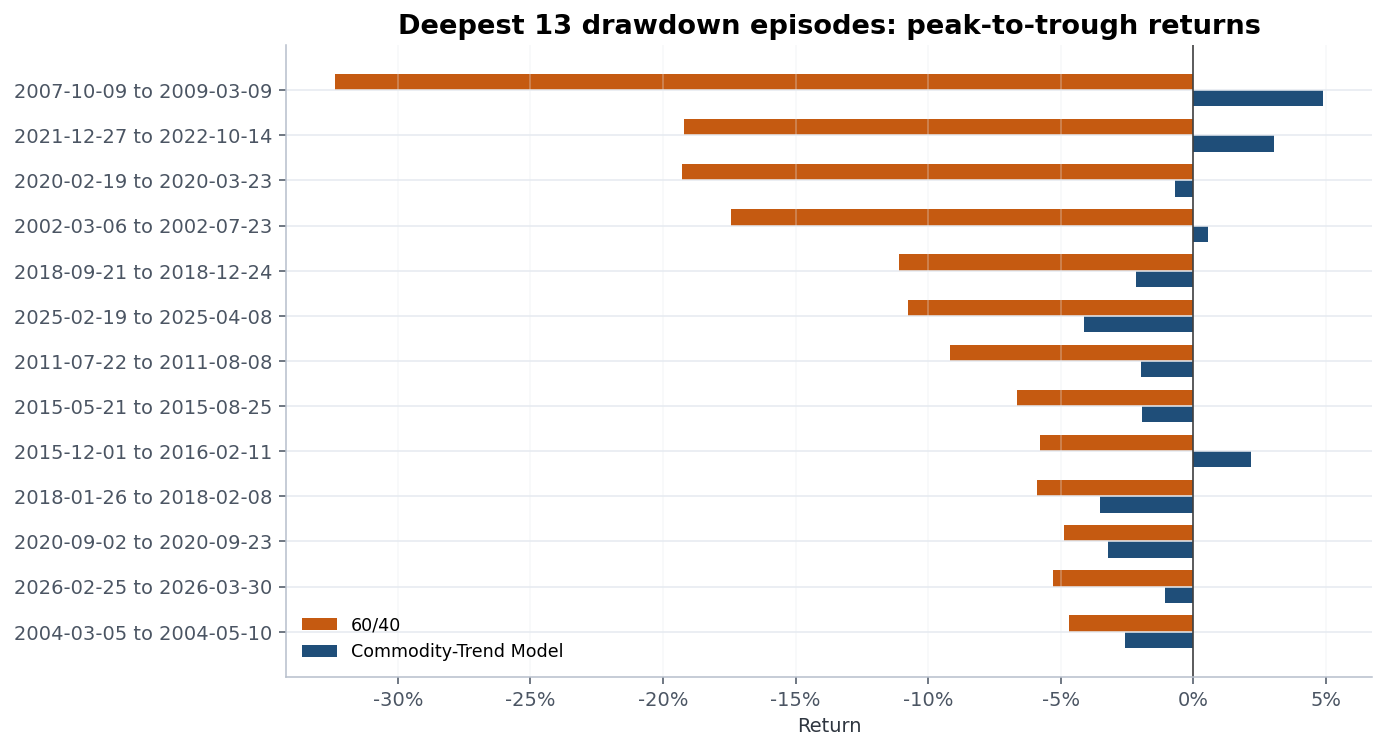

In [10]:
display(style_summary_table(presentation_table(episodes)))
plot_drawdown_episode_timeline_original(core_returns, episodes)
plot_drawdown_episode_bars_original(episodes)

In the two largest 60/40 drawdowns, Commodity-Trend gained while 60/40 lost: 2007-2009 (+4.9% vs -32.4%) and 2022 (+3.0% vs -19.2%). It did not offset the shorter 2020 COVID drawdown (-0.7% vs -19.3%) or the 2025 drawdown (-4.1% vs -10.7%).

Horizon,Bucket,Quantile Cutoff Q,N Windows,Bench Window Threshold,Bench Window Mean,Bench Window Median,Trend Window Mean,Trend Window Median,Excess Window Mean T Minus B,Trend Window Hit Rate Pos,Trend Ann Vol Monthly,Trend Sharpe Rf0 Monthly
21d_trailing,worst 10%,0.10,632,-0.03,-0.05,-0.04,-0.00,-0.00,0.04,35.0%,,
21d_trailing,rest,0.10,5687,-0.03,0.01,0.01,0.00,0.00,-0.01,53.1%,,
63d_trailing,worst 10%,0.10,628,-0.04,-0.07,-0.06,0.00,-0.00,0.07,47.3%,,
63d_trailing,rest,0.10,5649,-0.04,0.03,0.03,0.01,0.00,-0.02,56.2%,,
21d_trailing,worst 20%,0.20,1264,-0.01,-0.03,-0.03,-0.00,-0.00,0.03,36.6%,,
21d_trailing,rest,0.20,5055,-0.01,0.02,0.01,0.01,0.00,-0.01,55.0%,,
63d_trailing,worst 20%,0.20,1256,-0.01,-0.05,-0.04,0.00,-0.00,0.05,44.5%,,
63d_trailing,rest,0.20,5021,-0.01,0.04,0.03,0.01,0.01,-0.02,58.0%,,
calendar_month,worst 10%,0.10,30,-0.03,-0.04,-0.04,-0.00,-0.00,0.04,36.7%,7.1%,-0.68
calendar_month,rest,0.10,262,-0.03,0.01,0.01,0.00,0.00,-0.01,51.1%,7.4%,0.76


Bucket,N Days,Bench Dd Range Mid Approx,Trend Ann Mean From Daily,Trend Ann Vol,Trend Sharpe Rf0,Trend Hit Rate Pos,Bench Mean Daily
<= -20%,146,-0.23,-0.12,9.4%,-1.27,39.0%,-0.00
"(-20%, -10%]",566,-0.13,0.05,8.1%,0.63,44.0%,-0.00
"(-10%, -5%]",769,-0.07,0.02,8.2%,0.26,47.1%,-0.00
"(-5%, 0]",4858,-0.01,0.05,6.7%,0.77,45.4%,0.00
> 0 (noise),0,,,,,,


<Axes: title={'center': 'Commodity-Trend performance vs current 60/40 drawdown depth'}, ylabel='Annualized trend return'>

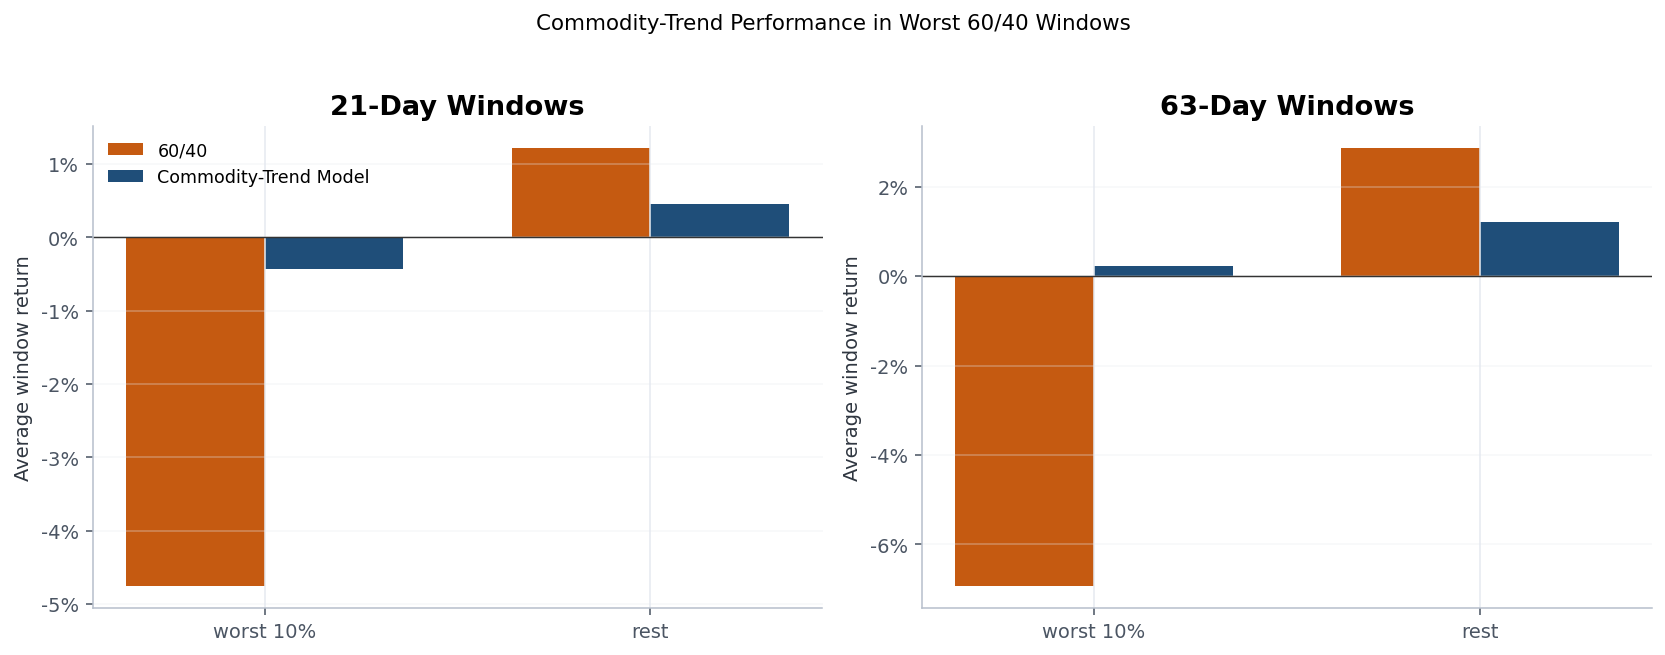

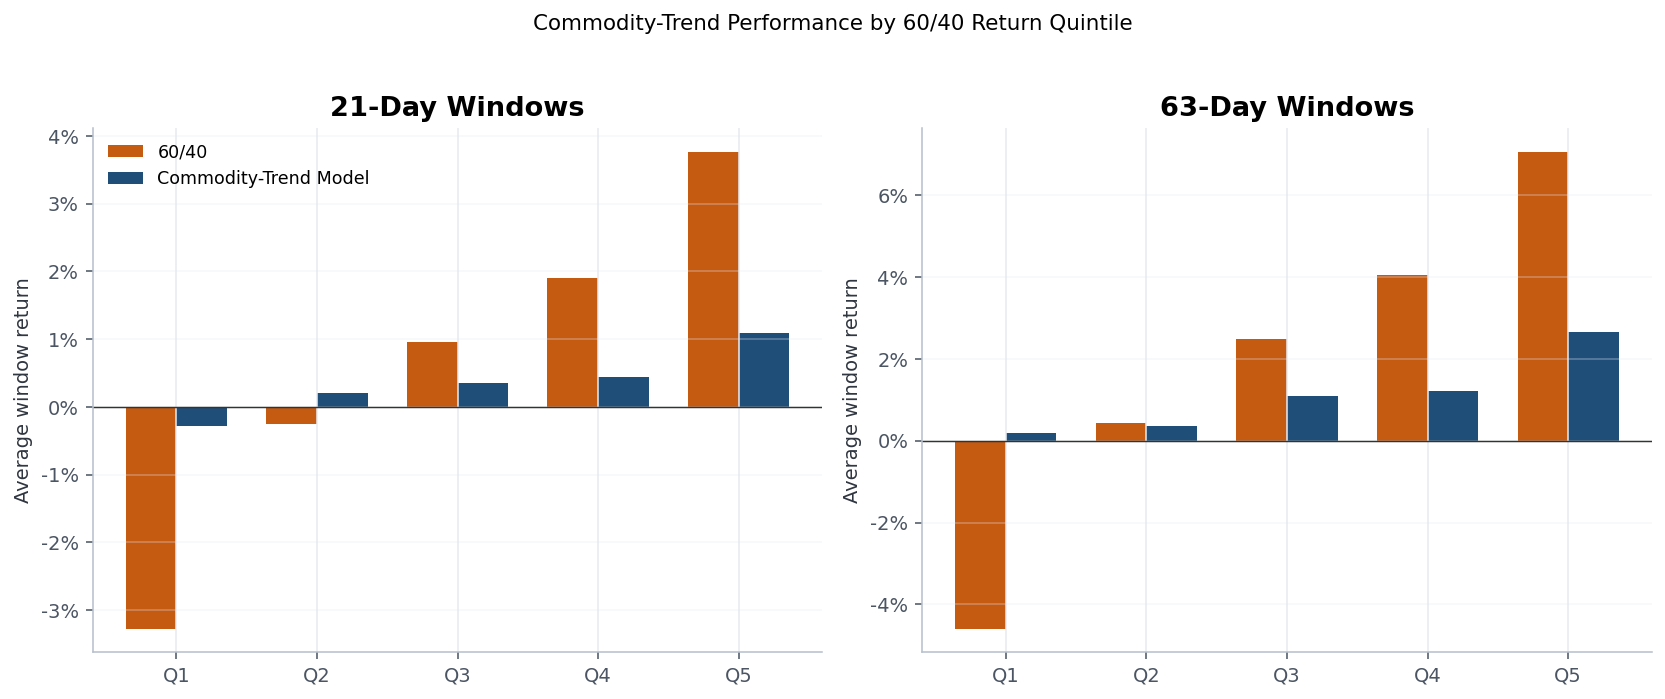

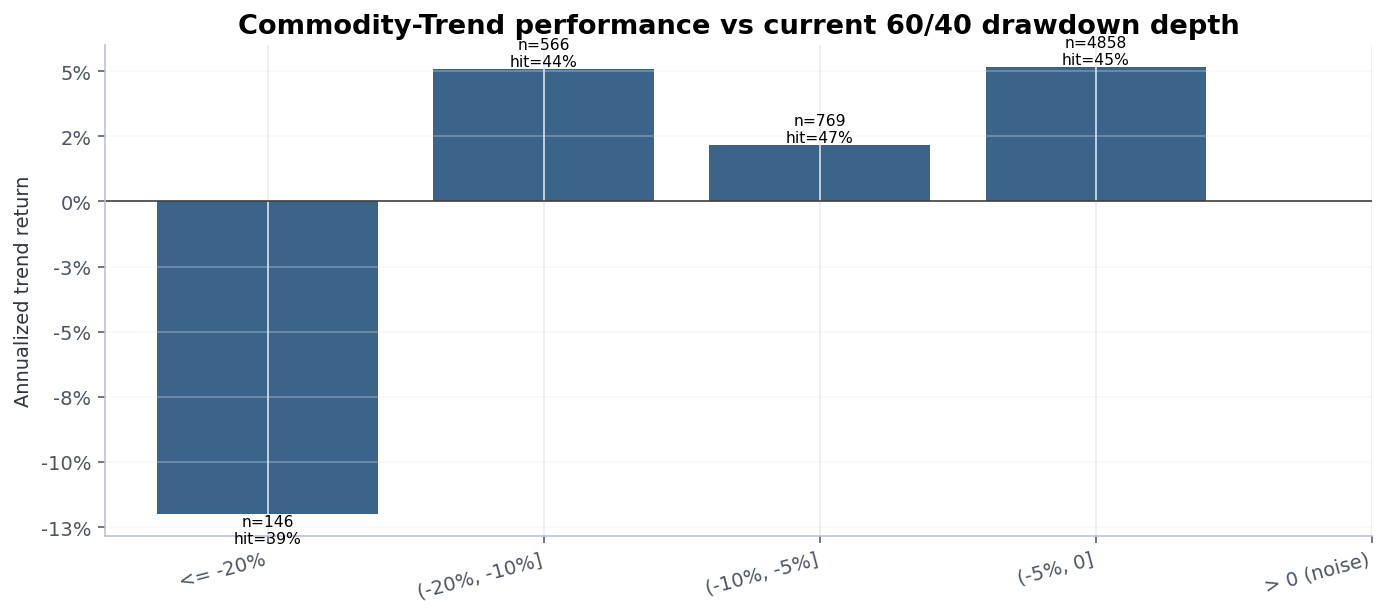

In [11]:
display(style_summary_table(presentation_table(quantile_windows)))
plot_stress_matched_panels_original(quantile_windows, q_use=0.10)
plot_quintile_matched_bars_original(core_returns)
display(style_summary_table(presentation_table(drawdown_buckets)))
plot_drawdown_buckets_original(drawdown_buckets)

In the worst 10% of 21-day 60/40 windows, 60/40 averaged -4.76% and Commodity-Trend -0.44% (+4.32pp active). In the worst 10% of 63-day windows, 60/40 averaged -6.94% and Commodity-Trend +0.21% (+7.15pp). Caveat from the drawdown-depth buckets: when 60/40 was already more than 20% below its prior high, Commodity-Trend's annualized return was -12.0%, so the model damps but does not invert deep stress.

### Asymmetric Capture Regression

Formula:

`r_Commodity-Trend = alpha + beta_up * r_60/40 * 1{r_60/40 > 0} + beta_down * r_60/40 * 1{r_60/40 < 0} + error`

Standard errors are HC1 robust.

In [12]:
display(style_regression_table(dual_beta_regression_table(core_returns)))

Term,Formula term,Estimate,HC1 SE,t-stat,N
Alpha,1,0.000281,0.000076,3.72,"6,340"
Beta up,r_60/40 * 1{r_60/40 > 0},0.073194,0.017381,4.21,"6,340"
Beta down,r_60/40 * 1{r_60/40 < 0},0.135628,0.019450,6.97,"6,340"


Up-day beta to 60/40 is 0.073 and down-day beta is 0.136. Both are small, so Commodity-Trend's return path is not just a scaled-down 60/40 in either direction.

## Part 5 — Equity and Bond Sleeves

Calendar-horizon active returns summarize when Commodity-Trend outperformed equity and bond sleeves.

Horizon,Comparator,N windows,Outright win rate,Risk-adjusted win rate,Mean active return,Median active return,Avg trend max DD,Avg comparator max DD
Month,Equity,291,38.1%,40.6%,-0.5%,-1.0%,-1.7%,-4.0%
Month,Bonds,291,50.5%,49.4%,0.1%,0.0%,-1.7%,-1.2%
Quarter,Equity,97,34.0%,37.2%,-1.5%,-3.2%,-3.2%,-7.3%
Quarter,Bonds,97,51.5%,52.1%,0.3%,0.1%,-3.2%,-2.1%
Year,Equity,24,20.8%,45.8%,-7.1%,-6.0%,-6.3%,-14.8%
Year,Bonds,24,45.8%,29.2%,1.0%,-0.6%,-6.3%,-4.2%


Horizon,Comparator,Condition,N windows,Outright win rate,Risk-adjusted win rate,Mean active return,Median active return,Avg trend max DD,Avg comparator max DD
Month,Bonds,Bond Return < 0,129,72.9%,73.6%,1.1%,0.6%,-1.7%,-1.6%
Month,Equity,Bond Return < 0,129,32.6%,31.4%,-0.9%,-1.1%,-1.7%,-3.6%
Month,Bonds,Equity Return < 0,97,37.1%,37.9%,-0.8%,-1.1%,-2.0%,-1.3%
Month,Equity,Equity Return < 0,97,83.5%,62.1%,3.5%,2.7%,-2.0%,-7.2%
Month,Bonds,Equity Return < 0 And Bond Return < 0,38,65.8%,72.2%,0.5%,0.5%,-2.1%,-1.8%
Month,Equity,Equity Return < 0 And Bond Return < 0,38,78.9%,52.8%,3.2%,2.7%,-2.1%,-6.8%
Quarter,Bonds,Bond Return < 0,37,67.6%,80.6%,2.7%,0.9%,-3.5%,-3.0%
Quarter,Equity,Bond Return < 0,37,27.0%,33.3%,-2.3%,-3.6%,-3.5%,-6.3%
Quarter,Bonds,Equity Return < 0,26,38.5%,36.0%,-1.1%,-1.2%,-4.2%,-2.5%
Quarter,Equity,Equity Return < 0,26,92.3%,68.0%,8.3%,9.8%,-4.2%,-14.4%


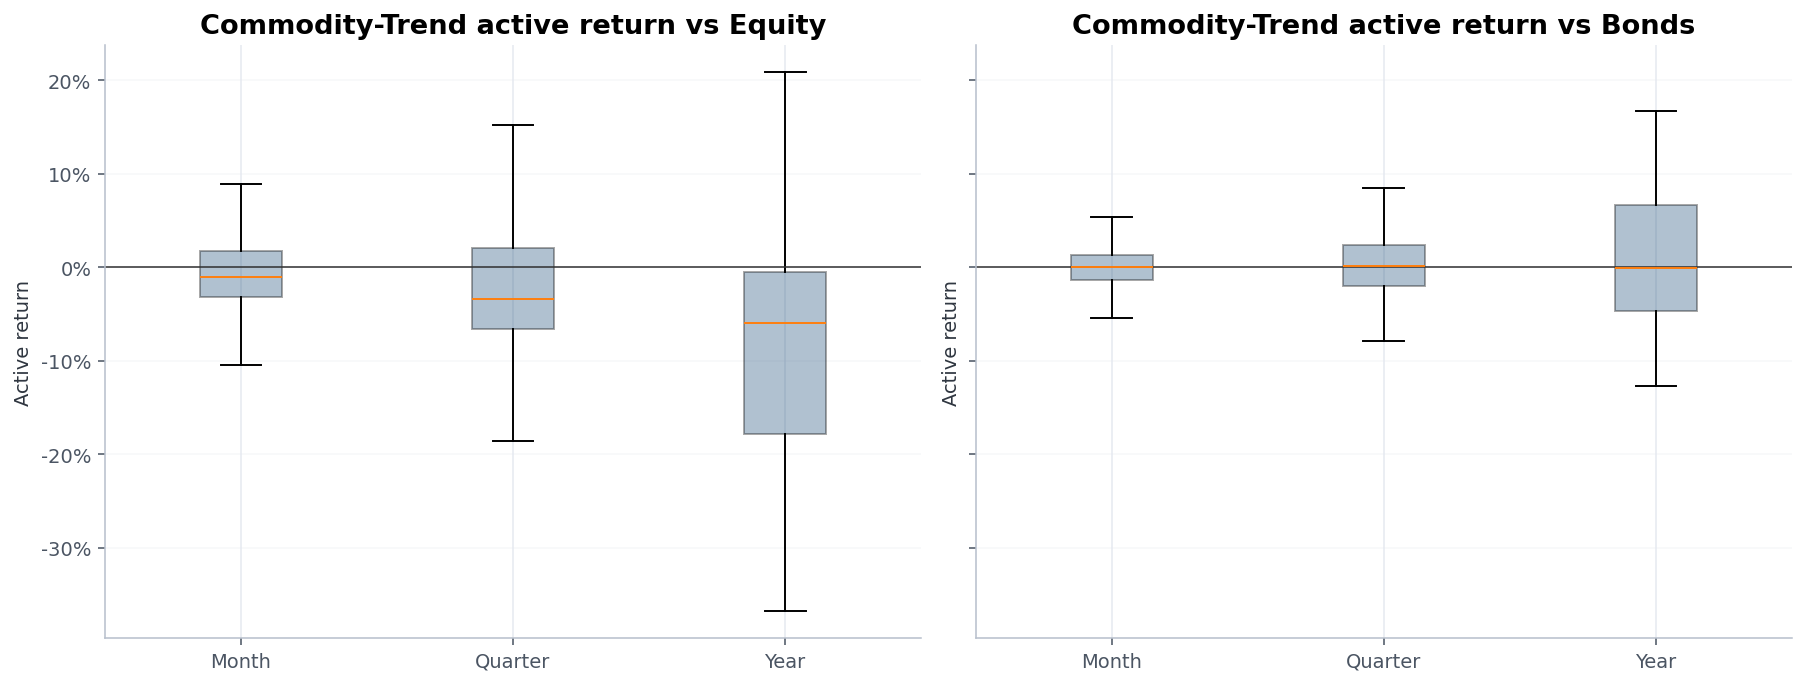

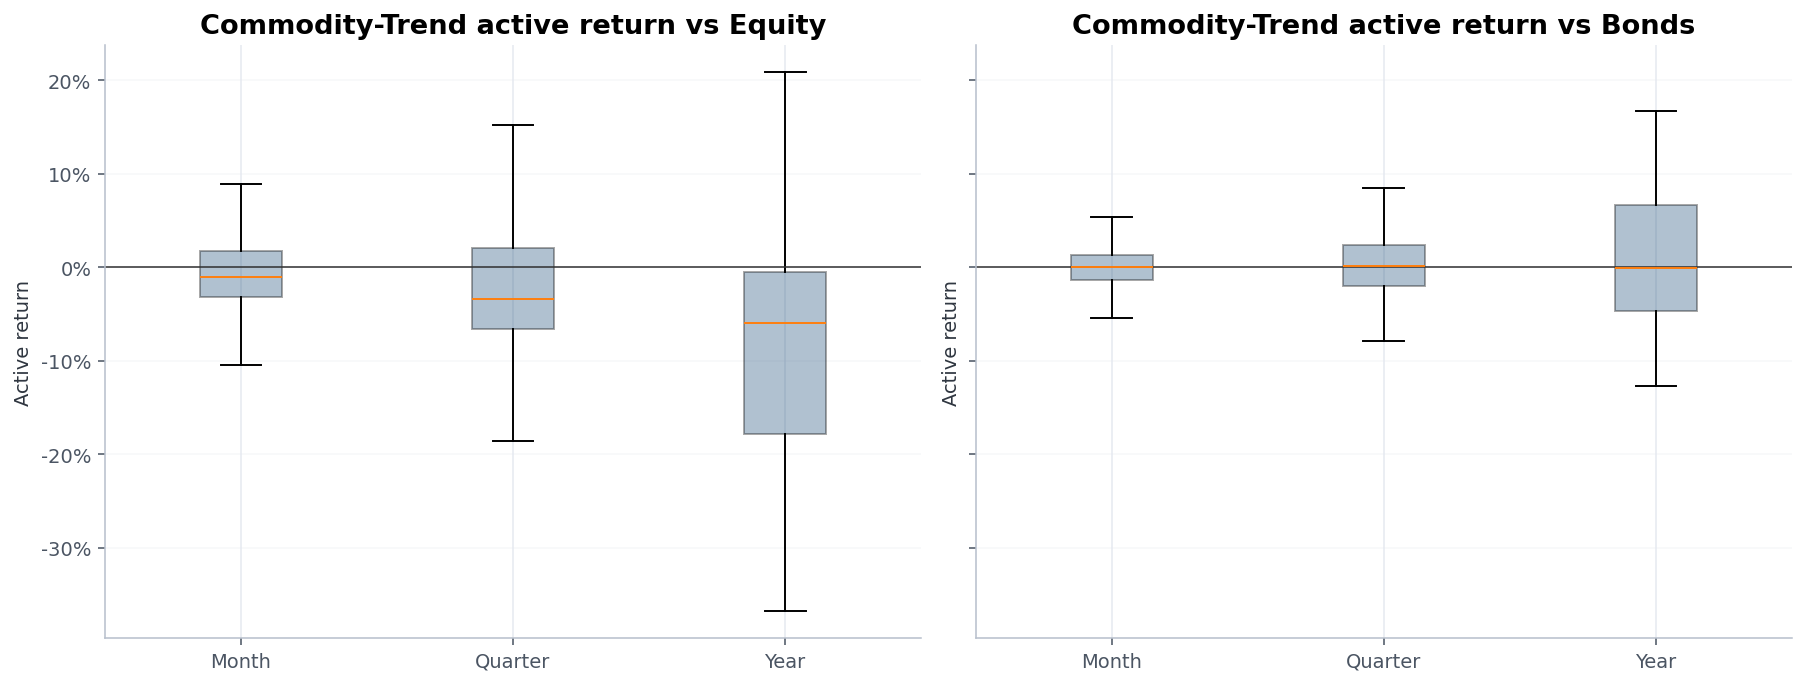

In [13]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter

from trend_analysis.original_style import STRATEGY_COLORS, _style_axes

TABLE_COLUMNS = [
    "horizon",
    "comparator",
    "condition",
    "n_windows",
    "outright_win_rate",
    "risk_adjusted_win_rate",
    "average_active_return",
    "median_active_return",
    "avg_trend_max_dd",
    "avg_comparator_max_dd",
    "avg_60_40_max_dd",
]

TABLE_RENAMES = {
    "horizon": "Horizon",
    "comparator": "Comparator",
    "condition": "Condition",
    "n_windows": "N windows",
    "outright_win_rate": "Outright win rate",
    "risk_adjusted_win_rate": "Risk-adjusted win rate",
    "trend_win_rate_vs_60_40": "Outright win rate",
    "avg_active_return_t_minus_6040": "Mean active return",
    "median_active_return_t_minus_6040": "Median active return",
    "average_active_return": "Mean active return",
    "median_active_return": "Median active return",
    "avg_trend_max_dd": "Avg trend max DD",
    "avg_comparator_max_dd": "Avg comparator max DD",
    "avg_60_40_max_dd": "Avg 60/40 max DD",
}

GROUP_COLORS = {
    "Month": "#EAF2F8",
    "Quarter": "#F3EAF8",
    "Year": "#EAF6EF",
}


def _title_value(value):
    if not isinstance(value, str):
        return value
    return value.replace("_", " ").title()


def _window_max_drawdown(series):
    growth = (1.0 + series.dropna()).cumprod()
    if growth.empty:
        return np.nan
    return (growth / growth.cummax() - 1.0).min()


def add_part5_drawdown_columns(summary_df, return_df):
    freq_map = {"month": "ME", "quarter": "QE", "year": "YE"}
    out = summary_df.copy()
    trend_dd = []
    comparator_dd = []
    for _, row in out.iterrows():
        horizon = str(row["horizon"]).lower()
        comparator = row["comparator"]
        freq = freq_map[horizon]
        needed = list(dict.fromkeys([COMMODITY_TREND, comparator, EQUITY, BONDS]))
        window_returns = (1.0 + return_df[needed].dropna(how="any")).resample(freq).prod() - 1.0
        max_dd = return_df[[COMMODITY_TREND, comparator]].dropna(how="any").resample(freq).agg(_window_max_drawdown)

        condition = str(row.get("condition", "")).lower()
        mask = pd.Series(True, index=window_returns.index)
        if "equity_return < 0" in condition:
            mask &= window_returns[EQUITY].lt(0)
        if "bond_return < 0" in condition:
            mask &= window_returns[BONDS].lt(0)

        selected = max_dd.reindex(window_returns.index[mask])
        trend_dd.append(selected[COMMODITY_TREND].mean())
        comparator_dd.append(selected[comparator].mean())

    out["avg_trend_max_dd"] = trend_dd
    out["avg_comparator_max_dd"] = comparator_dd
    return out


def compact_outperformance_table(df, default_condition="All windows"):
    out = df.copy()
    if "condition" not in out.columns:
        out["condition"] = default_condition
    cols = [col for col in TABLE_COLUMNS if col in out.columns]
    out = out[cols].rename(columns=TABLE_RENAMES)
    for col in ["Horizon", "Comparator", "Condition"]:
        if col in out.columns:
            out[col] = out[col].map(_title_value)
    return out


def compact_part6_table(df, include_comparator=True):
    out = df.copy()
    out["comparator"] = BENCHMARK_6040
    cols = [
        "horizon",
        "comparator",
        "condition",
        "n_windows",
        "trend_win_rate_vs_60_40",
        "avg_active_return_t_minus_6040",
        "median_active_return_t_minus_6040",
        "avg_trend_max_dd",
        "avg_60_40_max_dd",
    ]
    out = out[[col for col in cols if col in out.columns]].rename(columns=TABLE_RENAMES)
    if not include_comparator and "Comparator" in out.columns:
        out = out.drop(columns="Comparator")
    for col in ["Horizon", "Comparator", "Condition"]:
        if col in out.columns:
            out[col] = out[col].map(_title_value)
    return out


def compact_part6_counts_table(df):
    out = df[["horizon", "n_windows", "positive_corr_windows", "positive_corr_share", "avg_eq_bond_corr_positive"]].copy()
    out = out.rename(
        columns={
            "horizon": "Horizon",
            "n_windows": "N windows",
            "positive_corr_windows": "Positive-corr windows",
            "positive_corr_share": "Positive-corr share",
            "avg_eq_bond_corr_positive": "Mean corr when positive",
        }
    )
    out["Horizon"] = out["Horizon"].map(_title_value)
    return out


def style_grouped_extremes(df):
    pct_cols = [
        col
        for col in df.columns
        if "rate" in col.lower()
        or "return" in col.lower()
        or "share" in col.lower()
        or "corr" in col.lower()
        or "drawdown" in col.lower()
        or " dd" in col.lower()
    ]
    formats = {col: "{:.1%}" for col in pct_cols}
    if "N windows" in df.columns:
        formats["N windows"] = "{:,.0f}"
    if "Positive-corr windows" in df.columns:
        formats["Positive-corr windows"] = "{:,.0f}"

    def row_styles(row):
        color = GROUP_COLORS.get(row.get("Horizon"), "#FFFFFF")
        styles = [f"border-top: 2px solid {color};"] * len(row)
        if "Condition" in row.index:
            styles[row.index.get_loc("Condition")] += f" background-color: {color}; font-weight: 600;"
        elif "Horizon" in row.index:
            styles[row.index.get_loc("Horizon")] += f" background-color: {color}; font-weight: 600;"
        return styles

    styler = df.style.format(formats, na_rep="").apply(row_styles, axis=1)
    return (
        styler.set_properties(**{"text-align": "center"})
        .set_table_styles(
            [
                {"selector": "th", "props": [("text-align", "center"), ("font-weight", "600"), ("background-color", "#F7F9FC")]},
                {"selector": "td", "props": [("border-bottom", "1px solid #E6EAF0")]},
            ]
        )
        .hide(axis="index")
    )


part5_calendar_with_dd = add_part5_drawdown_columns(part5_calendar, returns)
part5_conditional_with_dd = add_part5_drawdown_columns(part5_conditional, returns)
part5_calendar_compact = compact_outperformance_table(part5_calendar_with_dd).drop(columns="Condition")
part5_conditional_compact = compact_outperformance_table(part5_conditional_with_dd).sort_values(["Horizon", "Condition", "Comparator"])

display(style_grouped_extremes(part5_calendar_compact))
display(style_grouped_extremes(part5_conditional_compact))
plot_part5_active_return_boxplots_original(returns)

Commodity-Trend beats equities only 38.1% of months, 34.0% of quarters, and 20.8% of years. Hit rates jump in down-equity windows: 83.5% of months (+3.50pp) and 92.3% of quarters (+8.31pp). Versus bonds it wins 50.5% of months overall and 72.9% in down-bond months (+1.08pp).

## Part 6 — Positive Stock-Bond Correlation

This section isolates environments where traditional stock-bond diversification was weaker and compares Commodity-Trend against 60/40.

In [14]:
part6_counts_compact = compact_part6_counts_table(part6_counts)
part6_conditional_compact = compact_part6_table(part6_conditional).sort_values(["Horizon", "Condition"])
part6_stress_compact = compact_part6_table(part6_stress).sort_values(["Horizon", "Condition"])

display(style_grouped_extremes(part6_counts_compact))
display(style_grouped_extremes(part6_conditional_compact))
display(style_grouped_extremes(part6_stress_compact))

Horizon,N windows,Positive-corr windows,Positive-corr share,Mean corr when positive
Month,291,72,24.7%,25.9%
Quarter,97,20,20.6%,17.9%
Year,24,4,16.7%,9.3%


Horizon,Comparator,Condition,N windows,Outright win rate,Mean active return,Median active return,Avg trend max DD,Avg 60/40 max DD
Month,60/40,Eq Bond Corr <= 0,219,42.9%,-0.2%,-0.4%,-1.6%,-2.4%
Month,60/40,Eq Bond Corr > 0,72,40.3%,-0.3%,-0.5%,-1.8%,-2.2%
Quarter,60/40,Eq Bond Corr <= 0,77,41.6%,-0.6%,-1.7%,-3.1%,-4.4%
Quarter,60/40,Eq Bond Corr > 0,20,30.0%,-1.4%,-2.0%,-3.8%,-4.2%
Year,60/40,Eq Bond Corr <= 0,20,40.0%,-3.3%,-2.7%,-5.7%,-8.8%
Year,60/40,Eq Bond Corr > 0,4,25.0%,-6.9%,-14.0%,-9.3%,-8.9%


Horizon,Comparator,Condition,N windows,Outright win rate,Mean active return,Median active return,Avg trend max DD,Avg 60/40 max DD
Month,60/40,Positive Corr And 60/40 Return < 0,23,69.6%,1.2%,1.1%,-2.4%,-4.0%
Month,60/40,Positive Corr And Bond Return < 0,43,55.8%,0.5%,0.1%,-1.9%,-2.7%
Month,60/40,Positive Corr And Equity Return < 0,22,72.7%,1.4%,1.3%,-2.5%,-4.0%
Month,60/40,Positive Corr And Equity Return < 0 And Bond Return < 0,18,77.8%,1.7%,1.5%,-2.3%,-4.4%
Quarter,60/40,Positive Corr And 60/40 Return < 0,7,71.4%,2.0%,0.4%,-5.7%,-6.9%
Quarter,60/40,Positive Corr And Bond Return < 0,13,46.2%,-0.1%,-1.2%,-4.3%,-4.8%
Quarter,60/40,Positive Corr And Equity Return < 0,6,83.3%,2.9%,1.2%,-6.0%,-7.4%
Quarter,60/40,Positive Corr And Equity Return < 0 And Bond Return < 0,6,83.3%,2.9%,1.2%,-6.0%,-7.4%
Year,60/40,Positive Corr And 60/40 Return < 0,1,100.0%,18.1%,18.1%,-11.3%,-19.7%
Year,60/40,Positive Corr And Bond Return < 0,1,100.0%,18.1%,18.1%,-11.3%,-19.7%


Stock-bond correlation was positive in 24.7% of months (72 obs) and 20.6% of quarters (20 obs). Across all positive-correlation months, Commodity-Trend beat 60/40 only 40.3% of the time (-0.34pp). The win rate rises to 69.6% (+1.24pp) when those months were also down for 60/40.

<Axes: title={'center': 'Commodity-Trend active return vs 60/40 by stock-bond correlation regime'}, ylabel='Active return'>

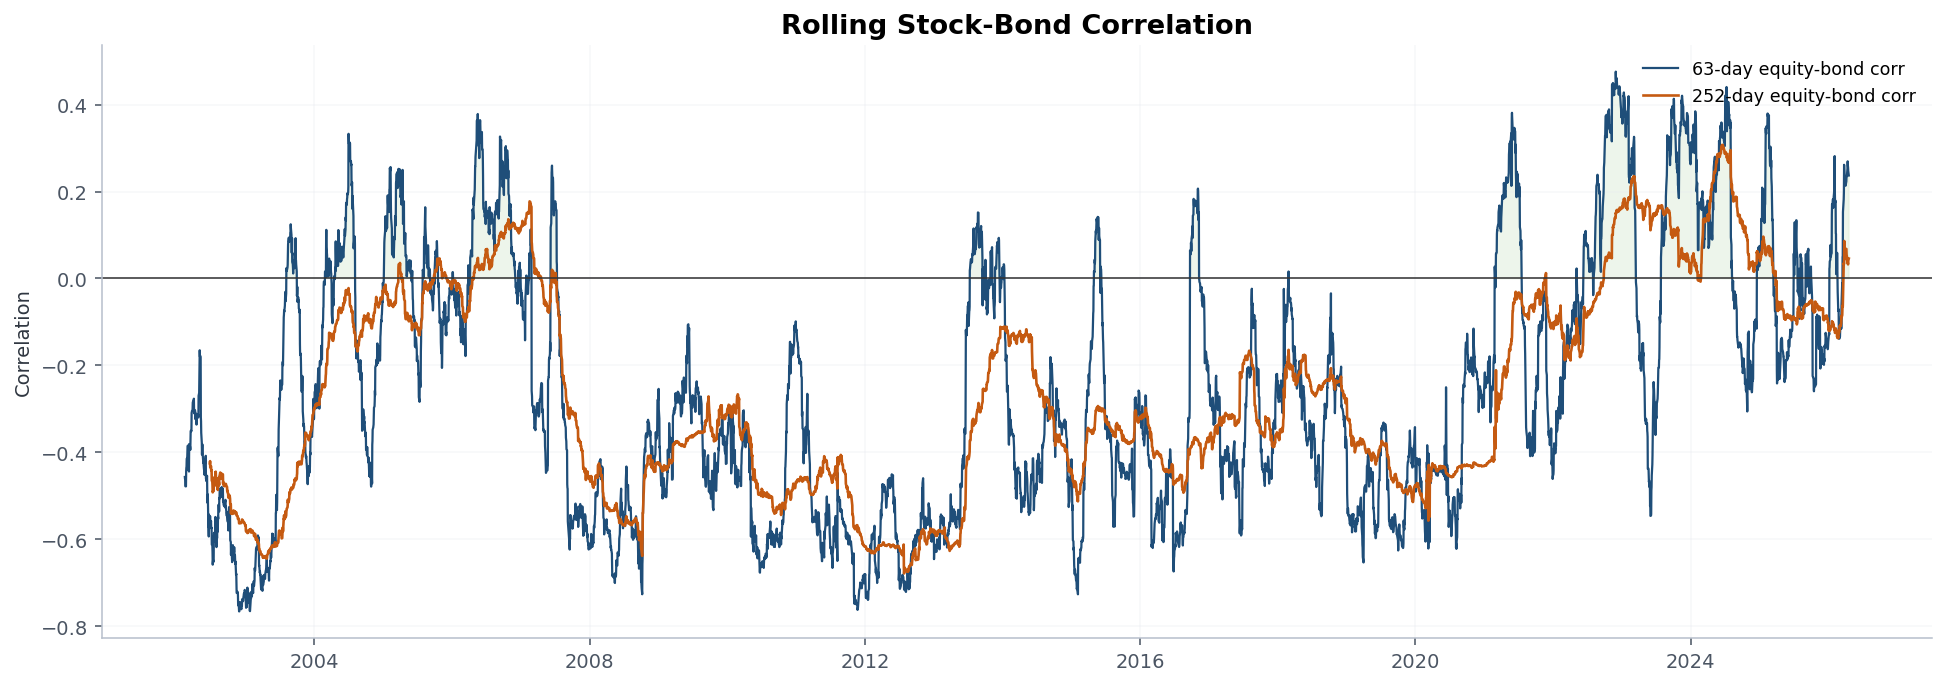

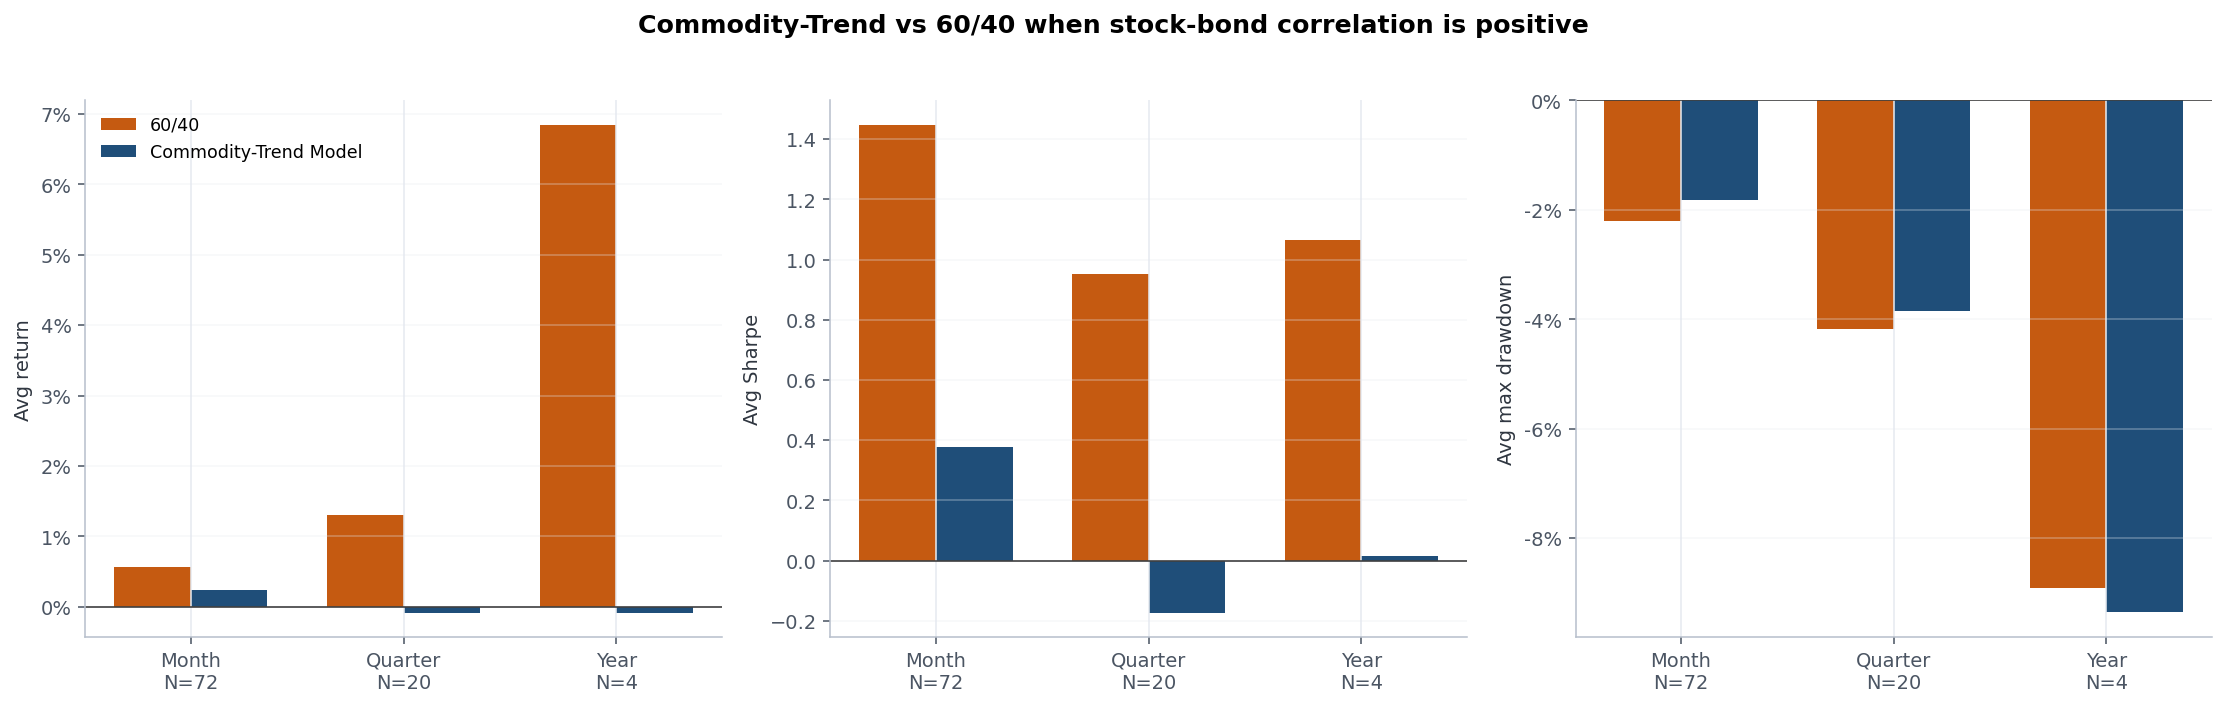

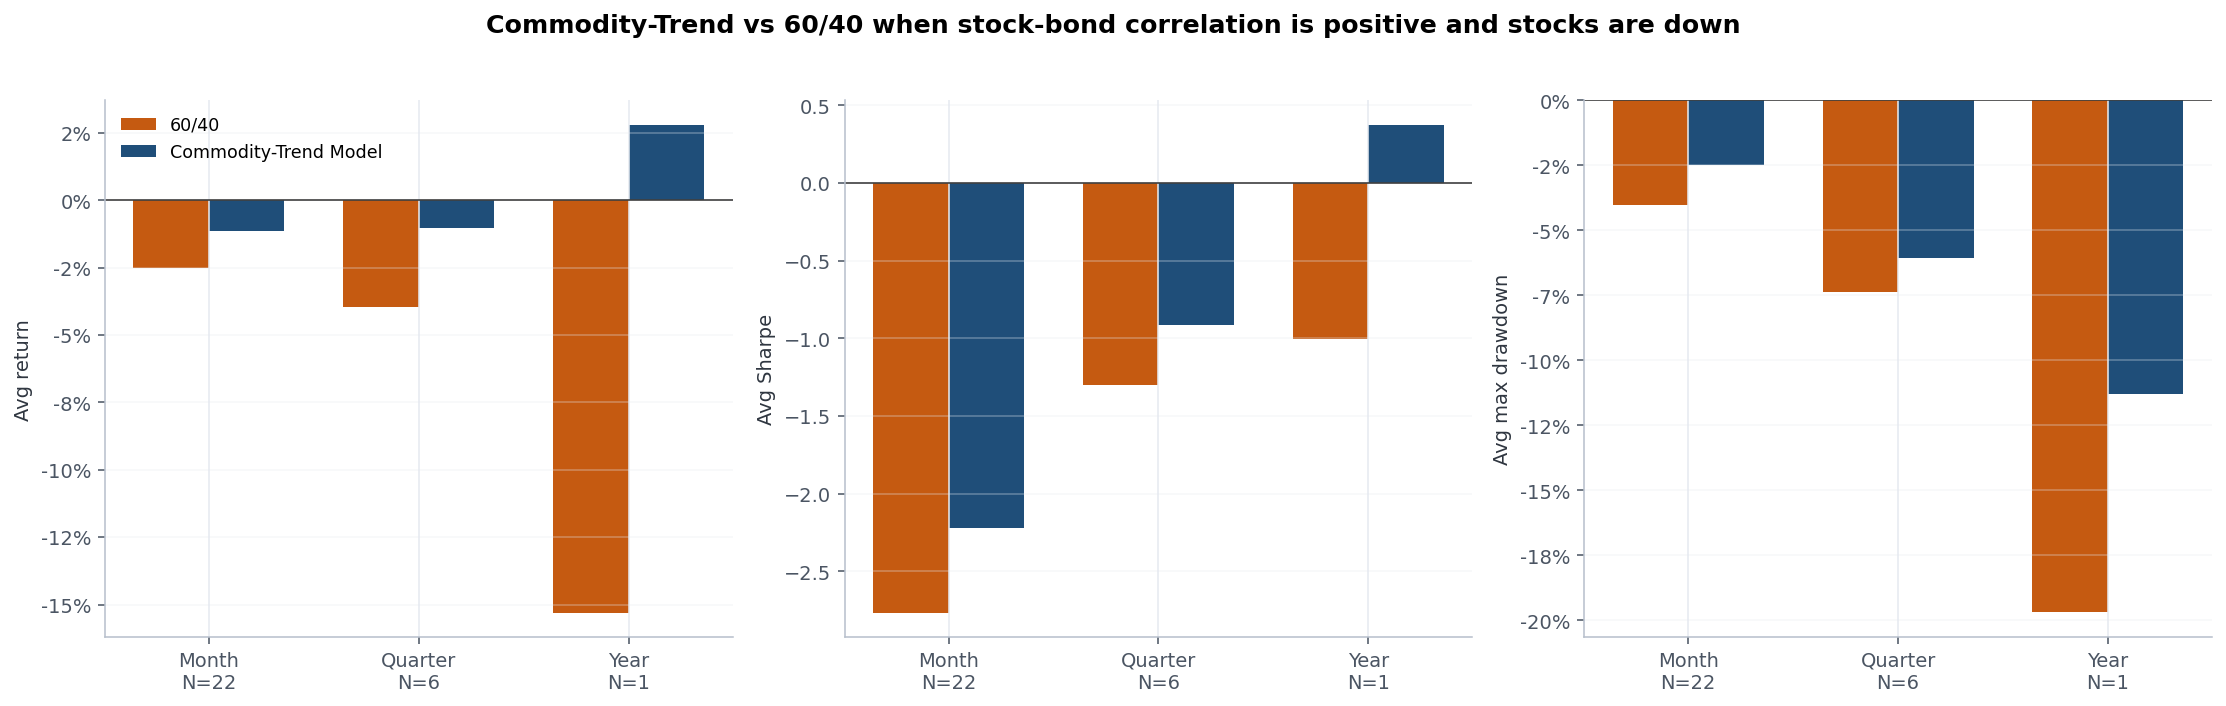

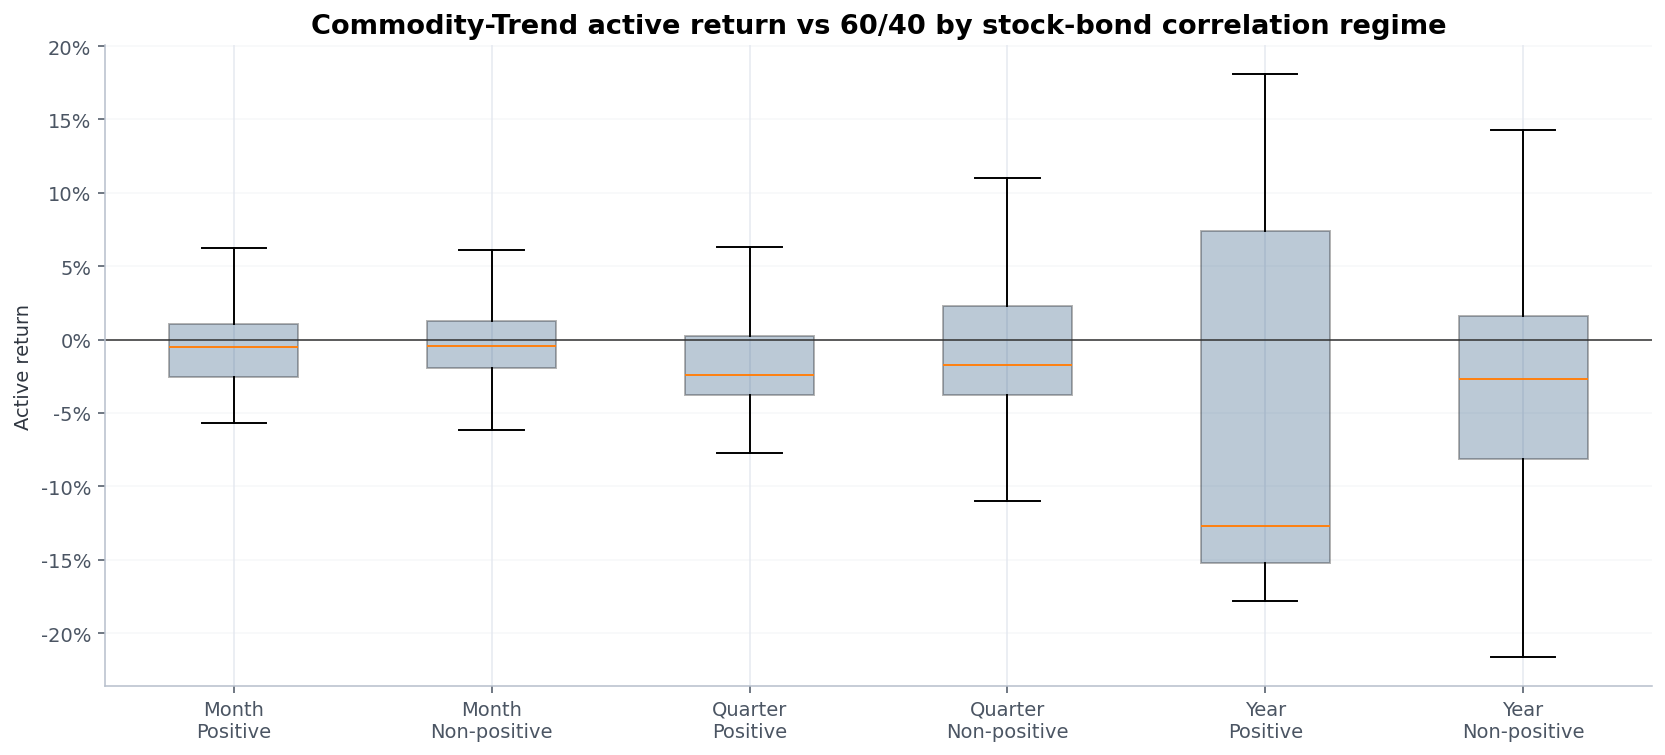

In [15]:
def _pct_axis(ax):
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0%}"))


def plot_part6_metric_panel_with_counts(df, title_context, condition=None):
    if condition is None:
        plot_df = df[df["regime"].eq("Positive stock-bond corr")].copy()
    else:
        plot_df = df[df["condition"].eq(condition)].copy()
    plot_df["horizon"] = plot_df["horizon"].str.title()
    plot_df["x_label"] = plot_df["horizon"] + "\nN=" + plot_df["n_windows"].astype(int).astype(str)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.9))
    specs = [
        ("avg_trend_return", "avg_60_40_return", "Avg return"),
        ("avg_trend_sharpe", "avg_60_40_sharpe", "Avg Sharpe"),
        ("avg_trend_max_dd", "avg_60_40_max_dd", "Avg max drawdown"),
    ]
    for ax, (trend_col, bench_col, ylabel) in zip(axes, specs):
        x = np.arange(len(plot_df))
        ax.bar(x - 0.18, plot_df[bench_col], width=0.36, color=STRATEGY_COLORS[BENCHMARK_6040], label="60/40")
        ax.bar(x + 0.18, plot_df[trend_col], width=0.36, color=STRATEGY_COLORS[COMMODITY_TREND], label=COMMODITY_TREND)
        ax.set_xticks(x)
        ax.set_xticklabels(plot_df["x_label"])
        ax.axhline(0, color="#333333", linewidth=0.8)
        ax.set_ylabel(ylabel)
        if "return" in trend_col or "dd" in trend_col:
            _pct_axis(ax)
        _style_axes(ax, "y")
    fig.suptitle(f"Commodity-Trend vs 60/40 when {title_context}", fontsize=13, fontweight="600", y=1.02)
    axes[0].legend(loc="best")
    plt.tight_layout()
    return fig


plot_stock_bond_corr_original(returns.dropna(subset=[EQUITY, BONDS]))
plot_part6_metric_panel_with_counts(part6_conditional, "stock-bond correlation is positive")
plot_part6_metric_panel_with_counts(
    part6_stress,
    "stock-bond correlation is positive and stocks are down",
    condition="positive corr and equity_return < 0",
)
plot_part6_active_return_boxplots_original(returns)

Across all positive-correlation windows, Commodity-Trend lagged 60/40 by -0.34pp per month, -1.39pp per quarter, and -6.93pp per year. The stress overlap is what matters: in positive-correlation 60/40-down months it won 69.6% (+1.24pp), and when stocks and bonds were both down it won 77.8% (+1.65pp).

## Portfolio Takeaway

Commodity-Trend works as a diversifying sleeve inside 60/40, not as a substitute. The value comes from low (and time-varying) correlation, smaller losses in the largest 60/40 drawdowns, and Sharpe improvement when added at conservative weights.